### Importing Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

### Loading Dataset

In [41]:
DATA_PATH = "../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA_2000_2024.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
display(df.head(10))

,county_fips5,yr,hpi_change,index_nsa,state,cz_name,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,...,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population
0,1001,2000,2.50,141.23,ALABAMA,AUTAUGA,1.0,200000.0,3.50,0.546615,...,0.0,0.0,0.0,0,4.1,0.000,1001.0,831.0,72778000.0,44021.0
1,1001,2001,3.44,146.08,ALABAMA,AUTAUGA,2.0,37000.0,4.25,0.295779,...,0.0,0.0,0.0,1041239,4.1,0.000,1001.0,766.0,71592000.0,44889.0
2,1001,2002,2.67,149.98,ALABAMA,AUTAUGA,0.0,0.0,0.00,0.378973,...,0.0,0.0,0.0,1080135,4.8,0.000,1001.0,730.0,78607000.0,45909.0
3,1001,2003,1.79,152.66,ALABAMA,AUTAUGA,2.0,58000.0,6.00,0.277611,...,0.0,0.0,0.0,1111465,5.0,0.245,1001.0,835.0,93128000.0,46800.0
4,1001,2004,2.92,157.12,ALABAMA,AUTAUGA,1.0,8000.0,3.50,0.411246,...,0.0,0.0,0.0,1283522,4.7,0.245,1001.0,908.0,111256000.0,48366.0
5,1001,2005,7.02,168.15,ALABAMA,AUTAUGA,6.0,19000.0,76.00,0.283690,...,0.0,0.0,0.0,1297102,3.8,0.245,1001.0,1062.0,132337000.0,49676.0
6,1001,2006,7.88,181.40,ALABAMA,AUTAUGA,1.0,0.0,1.80,0.495404,...,0.0,0.0,0.0,1384119,3.3,0.245,1001.0,1122.0,152119000.0,51328.0
7,1001,2007,4.51,189.59,ALABAMA,AUTAUGA,1.0,0.0,1.62,0.570198,...,0.0,0.0,0.0,1407555,3.4,0.275,1001.0,1017.0,141442000.0,52405.0
8,1001,2008,0.27,190.09,ALABAMA,AUTAUGA,0.0,0.0,0.00,0.435378,...,0.0,0.0,0.0,1283751,5.3,0.275,1001.0,633.0,97366000.0,53277.0
9,1001,2009,-1.79,186.69,ALABAMA,AUTAUGA,3.0,1580000.0,17.00,0.430504,...,0.0,0.0,0.0,1316046,8.9,0.275,1001.0,434.0,69414000.0,54135.0


### Checking Missing Values

In [42]:
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": (df.isna().mean() * 100).round(2)}
).sort_values("missing_count", ascending=False)

print(missing_summary)

                           missing_count  missing_pct
fire_frequency                     11144        16.30
heat_stress_index                  11144        16.30
drought_annual_mean_index          11144        16.30
fire_size                          11144        16.30
injuries_hurricane                 11051        16.16
damage_hurricane                   11051        16.16
deaths_hurricane                   11051        16.16
prop_rate                          10135        14.82
total_amt_purchase                  8358        12.22
total_home_purchase                 8358        12.22
real_gdp                            2939         4.30
unemployment_rate                   2786         4.07
hpi_change                           451         0.66
index_nsa                            358         0.52
total_population                      36         0.05
yr                                     0         0.00
flood_duration_hours                   0         0.00
flood_property_damage       

In [43]:
# Checking for duplicates
dup_mask = df.duplicated(subset=["county_fips5", "yr"], keep=False)
dup_rows_count = dup_mask.sum()
print("Rows involved in duplicates:", dup_rows_count)

dups = df.loc[dup_mask].sort_values(["county_fips5", "yr"])
print(dups.head())
print(df.shape)

Rows involved in duplicates: 0
Empty DataFrame
Columns: [county_fips5, yr, hpi_change, index_nsa, state, cz_name, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, deaths_hurricane, injuries_hurricane, damage_hurricane, real_gdp, unemployment_rate, prop_rate, county_fips, total_home_purchase, total_amt_purchase, total_population]
Index: []

[0 rows x 23 columns]
(68385, 23)


In [44]:
missing_by_year = df.groupby("yr").apply(lambda g: g.isna().sum()).sort_index()

print(missing_by_year)

      county_fips5  yr  hpi_change  index_nsa  state  cz_name  \
yr                                                              
2000             0   0           0          0      0        0   
2001             0   0           0          0      0        0   
2002             0   0           0          0      0        0   
2003             0   0           0          0      0        0   
2004             0   0           0          0      0        0   
2005             0   0           0          0      0        0   
2006             0   0           0          0      0        0   
2007             0   0           0          0      0        0   
2008             0   0           0          0      0        0   
2009             0   0           0          0      0        0   
2010             0   0           0          0      0        0   
2011             0   0           0          0      0        0   
2012             0   0           0          0      0        0   
2013             0   0   

In [45]:
zero_count = (df["index_nsa"] == 0).sum()
print("Zeros in index_nsa:", int(zero_count))

zeros_by_year = df.loc[df["index_nsa"] == 0].groupby("yr").size().sort_index()
print(zeros_by_year)

Zeros in index_nsa: 61
yr
2000     3
2006     1
2007     1
2008     1
2010     1
2011     6
2012     2
2014     6
2015    10
2016     9
2017     3
2018     8
2019    10
dtype: int64


In [46]:
# Droping rows where the target is exactly 0
df = df[df["index_nsa"] != 0].copy()

print("Remaining zeros in index_nsa:", (df["index_nsa"] == 0).sum())
print(df.shape)

zero_count = (df["index_nsa"] == 0).sum()
print("Zeros in index_nsa:", int(zero_count))

Remaining zeros in index_nsa: 0
(68324, 23)
Zeros in index_nsa: 0


### AUTOMATED DATA TYPE CLEANING

In [47]:
print("Standardizing numeric formatting...")

exclude_cols = {"state", "cz_name", "county_fips5"}
threshold = 0.99


def to_numeric_clean(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.replace(r"[,$%]", "", regex=True).str.strip()
    s = s.replace(
        {
            "nan": np.nan,
            "None": np.nan,
            "": np.nan,
            "(NA)": np.nan,
            "NA": np.nan,
            "N/A": np.nan,
        }
    )
    return pd.to_numeric(s, errors="coerce")


for c in df.columns:
    if c in exclude_cols or not pd.api.types.is_object_dtype(df[c]):
        continue

    converted = to_numeric_clean(df[c])
    non_null_before = df[c].notna().sum()

    if non_null_before == 0:
        continue

    success_rate = converted.notna().sum() / non_null_before

    if success_rate >= threshold:
        df[c] = converted
        print(f" [+] Converted {c} to numeric (Success: {success_rate*100:.1f}%)")
    else:
        print(f" [-] Skipped {c} (Not a numeric column)")

Standardizing numeric formatting...
 [+] Converted real_gdp to numeric (Success: 100.0%)


### COUNTY-SPECIFIC TREND IMPUTATION

In [48]:
print("Applying county-level trend projection for 2021-2024...")

# 1. Updating the list of columns to include your specific requests
cols_to_impute = [
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",  
    "real_gdp",
    "unemployment_rate",
    "prop_rate",
    "total_home_purchase",
    "total_amt_purchase",
    "total_population",
    "index_nsa",
    "hpi_change",
]

# 2. FORCE CLEAR step:
# For climate and specific macro cols, if 2021-2024 contain the same value (static median),
# we set them to NaN so the Trend Logic is forced to calculate unique values.
cols_to_force_trend = [
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "prop_rate",
    "total_home_purchase",
    "total_amt_purchase",
]

for col in cols_to_force_trend:
    df.loc[df["yr"] >= 2021, col] = np.nan

# Special handling for GDP and Unemployment
df.loc[df["yr"] == 2024, ["real_gdp", "unemployment_rate"]] = np.nan


# 3. Trend Projection Function
def apply_trend_imputation(group):
    """
    Fits a linear trend (Year -> Feature) using 2000-2020 data
    and projects it forward for missing values in 2021-2024.
    """
    for col in cols_to_impute:
        future_mask = (group["yr"] >= 2021) & (group[col].isna())

        if future_mask.any():
            history = group[(group["yr"] <= 2020) & (group[col].notna())]

            if len(history) >= 3:
                # Fitting linear trend: y = mx + b
                m, b = np.polyfit(history["yr"], history[col], 1)

                # Projecting the line into 2021-2024
                projections = m * group.loc[future_mask, "yr"] + b

                # Ensuring projections stay within 50% to 150% of historical range
                h_min, h_max = history[col].min(), history[col].max()
                group.loc[future_mask, col] = np.clip(
                    projections, h_min * 0.5, h_max * 1.5
                )

        # Filling any remaining NaNs with median
        hist_median = group.loc[group["yr"] <= 2020, col].median()
        group[col] = group[col].fillna(hist_median)

    return group


# Applying the logic county by county
df = df.groupby("county_fips5", group_keys=False).apply(apply_trend_imputation)

# Verification
missing_after = df[cols_to_impute].isna().sum()
print(f" [+] Imputation successful. Remaining NaNs: {missing_after.sum()}")

# Verifying that 2021-2024 now have DIFFERENT values
print("\n[+] Verification of dynamic values for 2021-2024 (Sample County):")
sample_fips = df["county_fips5"].iloc[0]
check_cols = ["yr", "heat_stress_index", "real_gdp", "total_home_purchase"]
print(df[df["county_fips5"] == sample_fips][check_cols].tail(5))

OUTPUT_PATH = "../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA_2000_2024_cleaned.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f" [+] File saved as: {OUTPUT_PATH}")
print(f" [+] Final Dataset Shape: {df.shape}")

Applying county-level trend projection for 2021-2024...
 [+] Imputation successful. Remaining NaNs: 0

[+] Verification of dynamic values for 2021-2024 (Sample County):
      yr  heat_stress_index      real_gdp  total_home_purchase
20  2020           0.375331  1.746979e+06          1065.000000
21  2021           0.429319  1.736001e+06           679.957143
22  2022           0.430420  1.895751e+06           674.524675
23  2023           0.431521  1.945909e+06           669.092208
24  2024           0.432621  2.186213e+06           663.659740
 [+] File saved as: ../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA_2000_2024_cleaned.csv
 [+] Final Dataset Shape: (68324, 23)


In [49]:
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": (df.isna().mean() * 100).round(2)}
).sort_values("missing_count", ascending=False)

print("\n[+] Final Missing Value Summary:")
print(missing_summary)


[+] Final Missing Value Summary:
                           missing_count  missing_pct
county_fips5                           0          0.0
fire_size                              0          0.0
total_amt_purchase                     0          0.0
total_home_purchase                    0          0.0
county_fips                            0          0.0
prop_rate                              0          0.0
unemployment_rate                      0          0.0
real_gdp                               0          0.0
damage_hurricane                       0          0.0
injuries_hurricane                     0          0.0
deaths_hurricane                       0          0.0
fire_frequency                         0          0.0
yr                                     0          0.0
drought_annual_mean_index              0          0.0
heat_stress_index                      0          0.0
flood_duration_hours                   0          0.0
flood_property_damage                  0        

### LOADING CLEANED DATASET

In [50]:
print("Loading cleaned dataset checkpoint...")

CLEAN_DATA_PATH = "../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA_2000_2024_cleaned.csv"

df = pd.read_csv(CLEAN_DATA_PATH, low_memory=False)
print(f" [+] Successfully loaded dataset. Shape: {df.shape}")
display(df.head(50))

Loading cleaned dataset checkpoint...
 [+] Successfully loaded dataset. Shape: (68324, 23)


,county_fips5,yr,hpi_change,index_nsa,state,cz_name,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,...,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population
0,1001,2000,2.50,141.23,ALABAMA,AUTAUGA,1.0,200000.0,3.50,0.546615,...,0.000000,0.0,0.000000e+00,0.000000e+00,4.100000,0.000000,1001.0,831.000000,7.277800e+07,44021.0
1,1001,2001,3.44,146.08,ALABAMA,AUTAUGA,2.0,37000.0,4.25,0.295779,...,0.000000,0.0,0.000000e+00,1.041239e+06,4.100000,0.000000,1001.0,766.000000,7.159200e+07,44889.0
2,1001,2002,2.67,149.98,ALABAMA,AUTAUGA,0.0,0.0,0.00,0.378973,...,0.000000,0.0,0.000000e+00,1.080135e+06,4.800000,0.000000,1001.0,730.000000,7.860700e+07,45909.0
3,1001,2003,1.79,152.66,ALABAMA,AUTAUGA,2.0,58000.0,6.00,0.277611,...,0.000000,0.0,0.000000e+00,1.111465e+06,5.000000,0.245000,1001.0,835.000000,9.312800e+07,46800.0
4,1001,2004,2.92,157.12,ALABAMA,AUTAUGA,1.0,8000.0,3.50,0.411246,...,0.000000,0.0,0.000000e+00,1.283522e+06,4.700000,0.245000,1001.0,908.000000,1.112560e+08,48366.0
5,1001,2005,7.02,168.15,ALABAMA,AUTAUGA,6.0,19000.0,76.00,0.283690,...,0.000000,0.0,0.000000e+00,1.297102e+06,3.800000,0.245000,1001.0,1062.000000,1.323370e+08,49676.0
6,1001,2006,7.88,181.40,ALABAMA,AUTAUGA,1.0,0.0,1.80,0.495404,...,0.000000,0.0,0.000000e+00,1.384119e+06,3.300000,0.245000,1001.0,1122.000000,1.521190e+08,51328.0
7,1001,2007,4.51,189.59,ALABAMA,AUTAUGA,1.0,0.0,1.62,0.570198,...,0.000000,0.0,0.000000e+00,1.407555e+06,3.400000,0.275000,1001.0,1017.000000,1.414420e+08,52405.0
8,1001,2008,0.27,190.09,ALABAMA,AUTAUGA,0.0,0.0,0.00,0.435378,...,0.000000,0.0,0.000000e+00,1.283751e+06,5.300000,0.275000,1001.0,633.000000,9.736600e+07,53277.0
9,1001,2009,-1.79,186.69,ALABAMA,AUTAUGA,3.0,1580000.0,17.00,0.430504,...,0.000000,0.0,0.000000e+00,1.316046e+06,8.900000,0.275000,1001.0,434.000000,6.941400e+07,54135.0


### MODEL EVALUATION UTILITIES

In [51]:
print("Loading evaluation metric helpers...")


def rmse(y_true, y_pred):
    """Calculates Root Mean Squared Error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def safe_mape(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error (MAPE) safely, ignoring zeros/NaNs."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_pred[mask] - y_true[mask]) / y_true[mask])) * 100.0)


def corr(y_true, y_pred):
    """Calculates Pearson Correlation Coefficient."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return np.nan
    return float(np.corrcoef(y_true[mask], y_pred[mask])[0, 1])


def print_metrics_block(title, y_true, y_pred):
    """Prints a standardized dashboard of all model performance metrics."""
    print(f"\n{'-'*40}")
    print(f"{title.upper()}")
    print(f"{'-'*40}")
    print(f"Count (n) : {int(len(y_true)):,}")
    print(f"MAE       : {float(mean_absolute_error(y_true, y_pred)):.4f}")
    print(f"RMSE      : {float(rmse(y_true, y_pred)):.4f}")
    print(f"R-Squared : {float(r2_score(y_true, y_pred)):.4f}")
    print(f"MAPE (%)  : {float(safe_mape(y_true, y_pred)):.4f}%")
    print(f"Pearson r : {float(corr(y_true, y_pred)):.4f}")
    print(f"{'-'*40}")

Loading evaluation metric helpers...


### DATA PREPARATION & TIME-SERIES SORTING

In [52]:
print("Formatting IDs and sorting time-series data...")

df["county_fips5"] = df["county_fips5"].astype(str).str.zfill(5)

df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df = df.sort_values(["county_fips5", "yr"]).reset_index(drop=True)

print(f" [+] FIPS codes formatted and data sorted chronologically.")
print(f" [+] Time horizon: {int(df['yr'].min())} - {int(df['yr'].max())}")
print("Raw shape:", df.shape)
print("Clean shape:", df.shape)

Formatting IDs and sorting time-series data...
 [+] FIPS codes formatted and data sorted chronologically.
 [+] Time horizon: 2000 - 2024
Raw shape: (68324, 23)
Clean shape: (68324, 23)


### TARGET VARIABLE GENERATION 

In [53]:
print("Generating 1-year forward target variable...")

TARGET = "index_nsa_next"

# Grouping by county and pull next year's HPI into the current year's row
df[TARGET] = df.groupby("county_fips5")["index_nsa"].shift(-1)

# Keeping only rows where current index and next-year target exist
# (This naturally drops 2024, as we do not have 2025 actuals yet)
required = ["county_fips5", "yr", "index_nsa", TARGET]
model_df = df.dropna(subset=required).copy()

# Explicitly restricting the training feature space to 2000–2023
model_df = model_df[model_df["yr"].between(2000, 2023)].copy()

print(f" [+] Target generated successfully: '{TARGET}'")
print(f" [+] Machine Learning Training Rows: {model_df.shape[0]:,}")
print(
    f" [+] Feature horizon: {int(model_df['yr'].min())} to {int(model_df['yr'].max())} (Predicting {int(model_df['yr'].min())+1} to {int(model_df['yr'].max())+1})"
)

Generating 1-year forward target variable...
 [+] Target generated successfully: 'index_nsa_next'
 [+] Machine Learning Training Rows: 65,538
 [+] Feature horizon: 2000 to 2023 (Predicting 2001 to 2024)


### FEATURE ENGINEERING

In [54]:
print("Engineering advanced macroeconomic and climate features...")

# Ensuring dataframe is perfectly sorted for time-series operations
model_df = model_df.sort_values(["county_fips5", "yr"]).copy()
g = model_df.groupby("county_fips5")

# 1. Macroeconomic Momentum (Deltas & Pct Changes)
# subtracts last year's rate from this year's rate.
model_df["delta_unemployment_rate"] = g["unemployment_rate"].diff(1)
model_df["delta_prop_rate"] = g["prop_rate"].diff(1)

# Calculatingg the Percentage Change. It needs to know if that economy is growing or shrinking. These features teach the model economic velocity.
for c in ["real_gdp", "total_population", "total_home_purchase", "total_amt_purchase"]:
    prev = g[c].shift(1)
    model_df[f"pct_{c}"] = (model_df[c] - prev) / prev.replace(0, np.nan) * 100.0

# 2. Log Transforms & Per-Capita Scaling
# A log transform "compresses" massive dollar amounts into a much smaller scale; formula: log(x+1)
# while preserving the proportional differences between rich and poor counties.
model_df["log_real_gdp"] = np.log1p(
    model_df["real_gdp"].clip(lower=0)
)  
model_df["log_total_population"] = np.log1p(model_df["total_population"].clip(lower=0))
model_df["log_total_home_purchase"] = np.log1p(
    model_df["total_home_purchase"].clip(lower=0)
)
model_df["log_total_amt_purchase"] = np.log1p(
    model_df["total_amt_purchase"].clip(lower=0)
)

# 3. Per-Capita & Ratios (Standardizing County Sizes)
# Divides total metrics by the county's population to create "Per Capita" (per person) metrics. In general it standartizes the data.
pop = model_df["total_population"].replace(0, np.nan)
hp = model_df["total_home_purchase"].replace(0, np.nan)

model_df["home_purchase_pc"] = model_df["total_home_purchase"] / pop
model_df["log_home_purchase_pc"] = np.log1p(model_df["home_purchase_pc"].clip(lower=0))
model_df["log_avg_purchase_amt"] = np.log1p(
    (model_df["total_amt_purchase"] / hp).clip(lower=0)
)

# 4. Autoregressive Housing Features (Lags & Rolling Means)
model_df["index_nsa_lag1"] = g["index_nsa"].shift(
    1
)  # it creates a column containing the Home Price Index (HPI) from 1 year ago.
model_df["index_nsa_lag2"] = g["index_nsa"].shift(2)
model_df["index_mom_1y"] = (
    model_df["index_nsa"] - model_df["index_nsa_lag1"]
)  # it calculates the "Momentum" (how many raw index points the property values jumped in the last year). If the model sees a momentum of +15, it knows the market is currently hot. If the momentum is -5, it knows the market is actively cooling down or crashing.
model_df["index_mom_2y"] = model_df["index_nsa"] - model_df["index_nsa_lag2"]

if "hpi_change" in model_df.columns:
    model_df["hpi_change_lag1"] = g["hpi_change"].shift(
        1
    )  # If creates a new column containing last year's percentage growth.
    model_df["hpi_change_roll3_mean"] = (
        g["hpi_change"].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )  # It looks at the HPI change from the past 3 years and averages them together.
    model_df["hpi_change_roll5_mean"] = (
        g["hpi_change"].shift(1).rolling(5).mean().reset_index(level=0, drop=True)
    )  # Look back at the 5 years before that, and calculate the average growth rate.

# It pushes the data down by one row within each county.
# This code creates new columns containing last year's unemployment rate, last year's GDP, and last year's population.
for c in ["unemployment_rate", "real_gdp", "total_population"]:
    model_df[f"{c}_lag1"] = g[c].shift(1)

# 5. Hazard Outlier Handling (Log scaling extreme damages)
# For highly destructive climate events, it finds the 99.5th percentile of damage (the absolute worst 0.5% of disasters).
# It then "caps" any damage amounts higher than that at the 99.5% limit.
# Note: Fire and Flood are now explicitly included in this stabilization step.
skew_cols = ["damage_hurricane", "flood_property_damage", "fire_size"]
for c in [col for col in skew_cols if col in model_df.columns]:
    base = model_df[c].clip(lower=0)
    model_df[f"log_{c}"] = np.log1p(base)

    train_cap = (
        model_df.loc[model_df["yr"].between(2000, 2019), c]
        .clip(lower=0)
        .quantile(0.995)
    )
    model_df[f"{c}_cap995"] = base.clip(upper=train_cap)

# 6. ADVANCED CLIMATE AMPLIFICATION (Strengthening Hazard Impact)

# It detects if a year is 'abnormally' hot or dry relative to the county's own 10-year history.
for col in ["heat_stress_index", "drought_annual_mean_index"]:
    if col in model_df.columns:
        local_avg = g[col].shift(1).rolling(window=10, min_periods=3).mean()
        model_df[f"{col}_anomaly"] = model_df[col] - local_avg

# Interaction Feature: It captures how climate stress impacts real estate differently in weak vs strong economies.
model_df["heat_econ_stress_interaction"] = (
    model_df["heat_stress_index"] * model_df["unemployment_rate"]
)

# Fire Intensity & Supply Shock: It combines frequency and size to identify high-risk zones.
# A large fire in a populated area (total_population) signals a housing supply shock.
model_df["fire_intensity_index"] = (
    model_df["fire_frequency"] * model_df["log_fire_size"]
)
model_df["fire_population_risk"] = (
    model_df["fire_intensity_index"] * model_df["log_total_population"]
)

# Cumulative Disaster Trauma: Markets react to repeated trauma. Proxy for insurance risk (3-year damage totals).
# Repeated fires, floods, or hurricanes cause long-term price suppression.
for c in ["damage_hurricane", "flood_property_damage", "fire_size"]:
    if c in model_df.columns:
        model_df[f"cumulative_{c}_3y"] = (
            g[c].rolling(window=3).sum().reset_index(level=0, drop=True)
        )

# Water Instability Index: Captures the "Weather Whiplash" effect (swinging between drought and flooding).
if "log_flood_damage" in model_df.columns:
    model_df["water_instability_index"] = (
        model_df["drought_annual_mean_index"] * model_df["log_flood_damage"]
    )

# Total Climate Risk Score: Combined heat, drought, fire, flood, and hurricane risk
hazards = ["heat_stress_index", "drought_annual_mean_index", "fire_intensity_index"]

if "log_flood_property_damage" in model_df.columns:
    hazards.append("log_flood_property_damage")

if "log_damage_hurricane" in model_df.columns:
    hazards.append("log_damage_hurricane")

model_df["total_climate_risk_score"] = model_df[hazards].sum(axis=1)

Engineering advanced macroeconomic and climate features...


### CHRONOLOGICAL TRAIN / VAL / TEST SPLITS

In [55]:
train_df = model_df[model_df["yr"].between(2000, 2019)].copy()
val_df = model_df[model_df["yr"].between(2020, 2022)].copy()
test_df = model_df[model_df["yr"] == 2023].copy()

print(f"\n [+] Feature Engineering Complete.")
print(
    f" [+] TRAIN Set : {train_df.shape[0]:,} rows (Features 2000-2019 -> Targets 2001-2020)"
)
print(
    f" [+] VAL Set   : {val_df.shape[0]:,} rows (Features 2020-2022 -> Targets 2021-2023)"
)
print(
    f" [+] TEST Set  : {test_df.shape[0]:,} rows (Features 2023      -> Targets 2024)"
)


 [+] Feature Engineering Complete.
 [+] TRAIN Set : 54,394 rows (Features 2000-2019 -> Targets 2001-2020)
 [+] VAL Set   : 8,358 rows (Features 2020-2022 -> Targets 2021-2023)
 [+] TEST Set  : 2,786 rows (Features 2023      -> Targets 2024)


### MATRIX ASSEMBLY & DATA LEAKAGE PREVENTION

In [56]:
print("Assembling final feature matrices...")

# Explicitly defining the feature space
feature_cols = [
    # Housing & Momentum
    "index_nsa",
    "index_nsa_lag1",
    "index_nsa_lag2",
    "index_mom_1y",
    "index_mom_2y",
    "hpi_change_lag1",
    "hpi_change_roll3_mean",
    "hpi_change_roll5_mean",
    # Macroeconomic Factors
    "real_gdp",
    "unemployment_rate",
    "prop_rate",
    "total_population",
    "total_home_purchase",
    "total_amt_purchase",
    "real_gdp_lag1",
    "unemployment_rate_lag1",
    "total_population_lag1",
    "delta_unemployment_rate",
    "delta_prop_rate",
    "pct_real_gdp",
    "pct_total_population",
    "pct_total_home_purchase",
    "pct_total_amt_purchase",
    # Per-Capita & Log Scales
    "log_real_gdp",
    "log_total_population",
    "log_total_home_purchase",
    "log_total_amt_purchase",
    "home_purchase_pc",
    "log_home_purchase_pc",
    "log_avg_purchase_amt",
    # Raw Climate Hazards
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "flood_property_damage",
    "damage_hurricane",
    "deaths_hurricane",
    "injuries_hurricane",
    # AMPLIFIED CLIMATE FEATURES
    "heat_stress_index_anomaly",
    "drought_annual_mean_index_anomaly",
    "heat_econ_stress_interaction",
    "fire_intensity_index",
    "fire_population_risk",
    "water_instability_index",
    "total_climate_risk_score",
    "cumulative_damage_hurricane_3y",
    "cumulative_flood_property_damage_3y",
    "cumulative_fire_size_3y",
    # Stabilized Hazards (Log/Cap)
    "log_damage_hurricane",
    "log_flood_property_damage",
    "log_fire_size",
    "damage_hurricane_cap995",
    "flood_property_damage_cap995",
    "fire_size_cap995",
    # Temporal Anchor
    "yr",
]

# Keeping only columns actively present in the dataframe
feature_cols = [c for c in feature_cols if c in train_df.columns]

# Spliting into Features (X) and Target (y)
X_train, y_train = train_df[feature_cols].copy(), train_df[TARGET].copy()
X_val, y_val = val_df[feature_cols].copy(), val_df[TARGET].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[TARGET].copy()

# Replacing any lingering infinite values with NaN safely
for X in (X_train, X_val, X_test):
    X.replace([np.inf, -np.inf], np.nan, inplace=True)


# Strict No-leakage Global imputation if there are NANs
# Calculating medians only on training data, apply to all sets

medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(medians)
X_val = X_val.fillna(medians)
X_test = X_test.fillna(medians)

print(f" [+] Assembled {len(feature_cols)} features.")
print(
    f" [+] Missing values remaining: TRAIN={X_train.isna().any().any()} | VAL={X_val.isna().any().any()} | TEST={X_test.isna().any().any()}"
)

Assembling final feature matrices...
 [+] Assembled 54 features.
 [+] Missing values remaining: TRAIN=False | VAL=False | TEST=False


### MODEL TRAINING: XGBOOST REGRESSOR

In [57]:
print("Training XGBoost Regressor model...")

# Log-Transforming the target to stabilize exponential growth variance
# we force the model to focus on predicting the percentage growth rather than raw point swings.
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# Defininmg heavily regularized model architecture to prevent overfitting
# Note: 'importance_type' is set to 'total_gain' to better capture climate impact.
xgb_model = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=10,
    reg_lambda=0.5,  # Ridge
    # alpha=0.5, # Lasso
    gamma=0.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=700,
    importance_type="total_gain",
)

# Fitting the model using early stopping on the validation set.
# # The model starts building its 10,000 trees using the Training Set (2000–2019).
# But after every single tree, it takes a test using the Validation Set (2020–2022).
xgb_model.fit(X_train, y_train_log, eval_set=[(X_val, y_val_log)], verbose=500)

# Inversing log-transform predictions back to the original HPI scale.
# It translates the model's output back into normal, human-readable Home Price Index numbers.
val_pred = np.expm1(xgb_model.predict(X_val))
test_pred = np.expm1(xgb_model.predict(X_test))

print(
    f"\n [+] Training stopped at best iteration: {getattr(xgb_model, 'best_iteration', 'N/A')}"
)
print_metrics_block(
    f"VALIDATION SET (Predicting {int(val_df['yr'].min())+1}-{int(val_df['yr'].max())+1})",
    y_val,
    val_pred,
)
print_metrics_block(
    f"TEST SET (Predicting {int(test_df['yr'].min())+1})", y_test, test_pred
)

Training XGBoost Regressor model...
[0]	validation_0-rmse:0.68982
[500]	validation_0-rmse:0.10576
[1000]	validation_0-rmse:0.10658
[1195]	validation_0-rmse:0.10646

 [+] Training stopped at best iteration: 496

----------------------------------------
VALIDATION SET (PREDICTING 2021-2023)
----------------------------------------
Count (n) : 8,358
MAE       : 35.7064
RMSE      : 64.9516
R-Squared : 0.9543
MAPE (%)  : 8.2698%
Pearson r : 0.9831
----------------------------------------

----------------------------------------
TEST SET (PREDICTING 2024)
----------------------------------------
Count (n) : 2,786
MAE       : 26.6897
RMSE      : 73.4334
R-Squared : 0.9532
MAPE (%)  : 5.8936%
Pearson r : 0.9786
----------------------------------------


### ROW-LEVEL RESULTS & RESIDUAL ANALYSIS

In [58]:
print("Generating row-level out-of-sample results...")

def build_results_table(df, y_actual, y_predicted):
    """Helper function to build a standardized results table with error metrics."""
    table = pd.DataFrame(
        {
            "county_fips5": df["county_fips5"].astype(str).str.zfill(5),
            "feature_year": df["yr"].values,
            "target_year": (df["yr"] + 1).values,
            "actual_hpi": y_actual.values if hasattr(y_actual, "values") else y_actual,
            "predicted_hpi": y_predicted,
        }
    )

    # Adding climate context to the results to help investigate residuals
    if "total_climate_risk_score" in df.columns:
        table["climate_risk_score"] = df["total_climate_risk_score"].values

    table["error"] = table["predicted_hpi"] - table["actual_hpi"]
    table["abs_error"] = table["error"].abs()
    table["pct_error"] = (table["error"] / table["actual_hpi"]) * 100.0

    return table


# Building Tables
val_table = build_results_table(val_df, y_val, val_pred)
test_table = build_results_table(test_df, y_test, test_pred)

# Displaying Validation Results
print(f"\n{'-'*50}\nVALIDATION SET: SAMPLE PREDICTIONS\n{'-'*50}")
display(val_table.head(10))

print(f"\n{'-'*50}\nVALIDATION SET: TOP 10 WORST ERRORS (Investigate These)\n{'-'*50}")
# Investigating if high errors correlate with high climate risk scores
display(val_table.sort_values("abs_error", ascending=False).head(10))

# Display Test Results
print(f"\n{'-'*50}\nTEST SET (2024): SAMPLE PREDICTIONS\n{'-'*50}")
display(test_table.head(10))

print(f"\n{'-'*50}\nTEST SET (2024): TOP 10 WORST ERRORS (Investigate These)\n{'-'*50}")
display(test_table.sort_values("abs_error", ascending=False).head(10))

Generating row-level out-of-sample results...

--------------------------------------------------
VALIDATION SET: SAMPLE PREDICTIONS
--------------------------------------------------


,county_fips5,feature_year,target_year,actual_hpi,predicted_hpi,climate_risk_score,error,abs_error,pct_error
20,01001,2020,2021,207.76,197.452209,47.436004,-10.307791,10.307791,-4.961393
21,01001,2021,2022,236.89,213.045273,129.481983,-23.844727,23.844727,-10.065738
22,01001,2022,2023,259.05,253.114410,125.518859,-5.935590,5.935590,-2.291291
45,01003,2020,2021,474.46,449.295410,370.623438,-25.164590,25.164590,-5.303838
46,01003,2021,2022,556.96,497.155487,770.835660,-59.804513,59.804513,-10.737668
47,01003,2022,2023,622.63,606.797913,773.812663,-15.832087,15.832087,-2.542776
70,01005,2020,2021,239.23,220.973572,47.566694,-18.256428,18.256428,-7.631329
71,01005,2021,2022,271.15,240.628510,130.138689,-30.521490,30.521490,-11.256312
72,01005,2022,2023,282.35,282.992462,133.555019,0.642462,0.642462,0.227541
95,01007,2020,2021,182.76,170.778259,51.151067,-11.981741,11.981741,-6.555997



--------------------------------------------------
VALIDATION SET: TOP 10 WORST ERRORS (Investigate These)
--------------------------------------------------


,county_fips5,feature_year,target_year,actual_hpi,predicted_hpi,climate_risk_score,error,abs_error,pct_error
4722,06075,2021,2022,2678.37,1443.731323,50.640318,-1234.638677,1234.638677,-46.096644
4797,06081,2021,2022,2439.61,1404.702515,576.282045,-1034.907485,1034.907485,-42.421022
4721,06075,2020,2021,2408.98,1448.017822,5.586031,-960.962178,960.962178,-39.890833
4847,06085,2021,2022,2658.54,1731.994873,1373.783088,-926.545127,926.545127,-34.851653
4848,06085,2022,2023,2825.72,1941.798340,1406.904416,-883.921660,883.921660,-31.281290
4846,06085,2020,2021,2297.50,1458.481079,1587.251598,-839.018921,839.018921,-36.518778
3796,06001,2020,2021,2235.72,1404.731323,1171.768122,-830.988677,830.988677,-37.168728
4773,06079,2022,2023,2563.16,1801.338013,1543.336894,-761.821987,761.821987,-29.721983
40907,36047,2021,2022,2383.86,1629.912476,478.528669,-753.947524,753.947524,-31.627173
40906,36047,2020,2021,2231.91,1503.563965,598.974269,-728.346035,728.346035,-32.633307



--------------------------------------------------
TEST SET (2024): SAMPLE PREDICTIONS
--------------------------------------------------


,county_fips5,feature_year,target_year,actual_hpi,predicted_hpi,climate_risk_score,error,abs_error,pct_error
23,01001,2023,2024,280.30,273.541718,121.573502,-6.758282,6.758282,-2.411089
48,01003,2023,2024,638.45,678.585449,764.354571,40.135449,40.135449,6.286389
73,01005,2023,2024,275.27,288.014465,136.981059,12.744465,12.744465,4.629805
98,01007,2023,2024,253.32,240.361359,177.680529,-12.958641,12.958641,-5.115522
123,01009,2023,2024,302.73,289.281799,160.451266,-13.448201,13.448201,-4.442309
148,01013,2023,2024,242.74,219.194077,281.070402,-23.545923,23.545923,-9.700059
173,01015,2023,2024,447.39,450.087982,345.904489,2.697982,2.697982,0.603049
198,01017,2023,2024,321.72,335.314270,157.153341,13.594270,13.594270,4.225497
223,01019,2023,2024,274.69,232.163132,233.114004,-42.526868,42.526868,-15.481768
248,01021,2023,2024,339.62,339.718658,301.447556,0.098658,0.098658,0.029050



--------------------------------------------------
TEST SET (2024): TOP 10 WORST ERRORS (Investigate These)
--------------------------------------------------


,county_fips5,feature_year,target_year,actual_hpi,predicted_hpi,climate_risk_score,error,abs_error,pct_error
4724,06075,2023,2024,2720.94,1576.648682,53.965236,-1144.291318,1144.291318,-42.055000
4849,06085,2023,2024,2983.76,1870.404175,1442.911574,-1113.355825,1113.355825,-37.313853
3799,06001,2023,2024,2571.78,1489.992188,673.502408,-1081.787813,1081.787813,-42.063777
4874,06087,2023,2024,2416.52,1424.147461,389.586340,-992.372539,992.372539,-41.066184
64445,53033,2023,2024,2431.17,1511.857300,118.932993,-919.312700,919.312700,-37.813592
4774,06079,2023,2024,2629.12,1778.619263,1562.643981,-850.500737,850.500737,-32.349255
40909,36047,2023,2024,2481.50,1675.671387,468.866317,-805.828613,805.828613,-32.473448
27483,25025,2023,2024,2378.55,1615.812988,1.886003,-762.737012,762.737012,-32.067310
4824,06083,2023,2024,2520.53,1782.809326,703.457165,-737.720674,737.720674,-29.268474
4249,06037,2023,2024,2356.07,1729.298096,5246.509394,-626.771904,626.771904,-26.602431


### PREDICTED VS. ACTUAL SCATTER PLOTS

Generating diagnostic scatter plots...


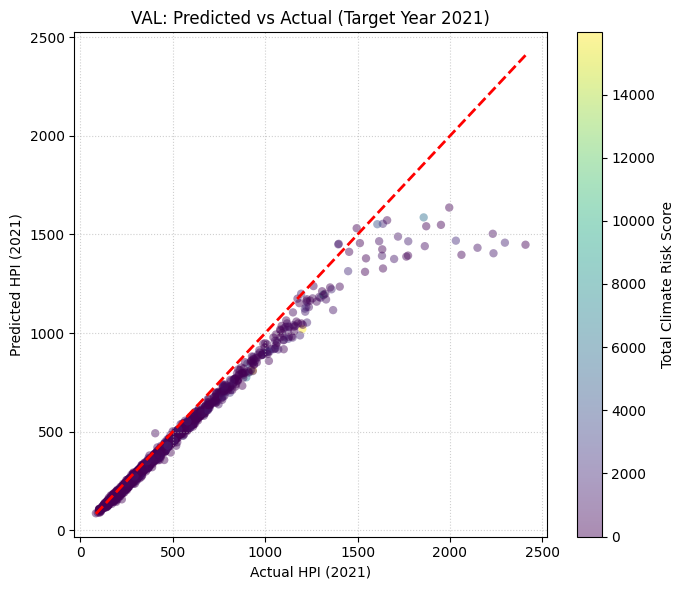

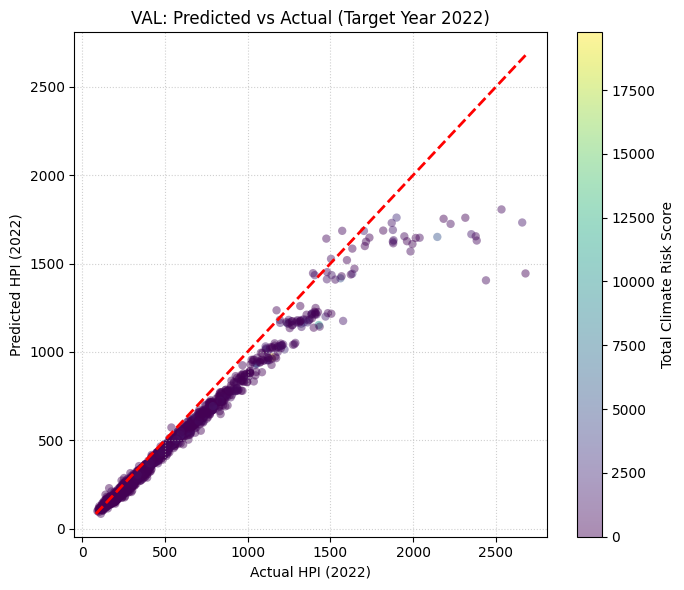

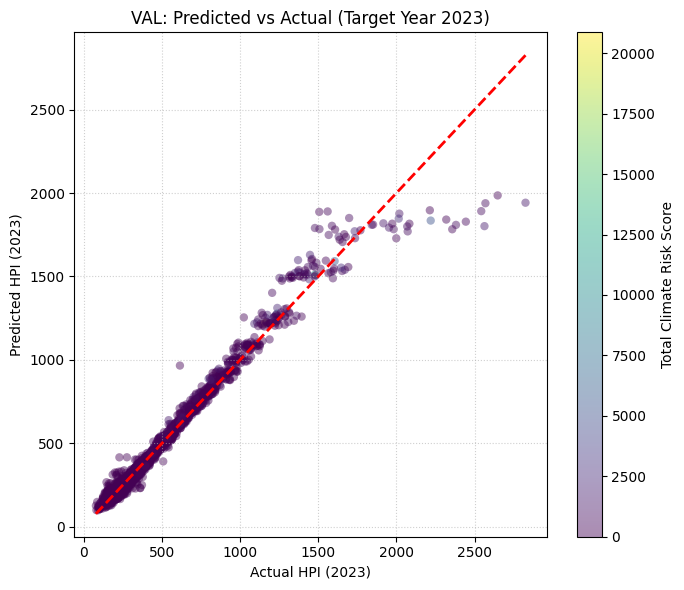

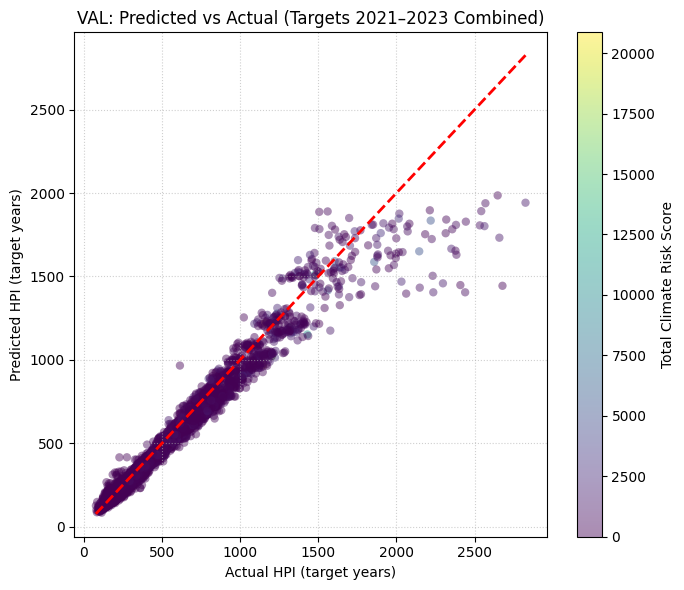

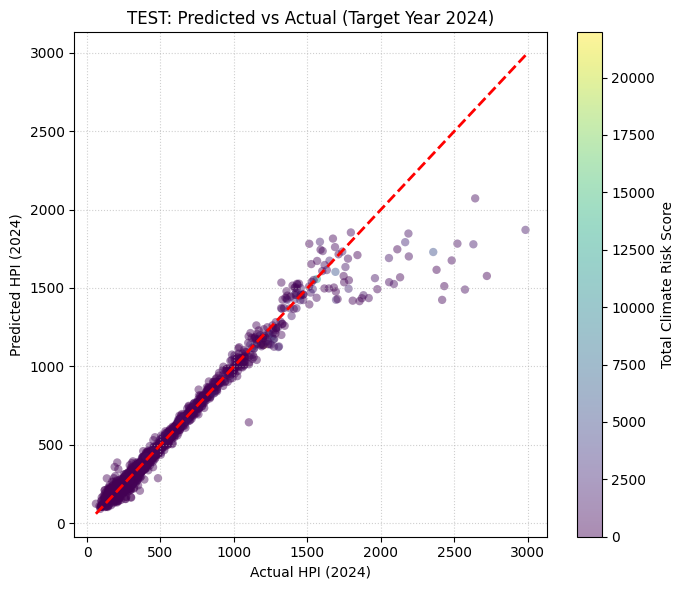

In [59]:
print("Generating diagnostic scatter plots...")


def plot_pred_vs_actual(table, title, label):
    """Helper function to generate standardized Predicted vs. Actual scatter plots."""
    plt.figure(figsize=(7, 6))

    actual = table["actual_hpi"]
    predicted = table["predicted_hpi"]

    # If climate risk score exists, use it to color the points
    # High-risk counties will appear in a different hue to see if they are the outliers
    if "climate_risk_score" in table.columns:
        sc = plt.scatter(
            actual,
            predicted,
            c=table["climate_risk_score"],
            cmap="viridis",
            alpha=0.45,
            edgecolors="none",
        )
        cbar = plt.colorbar(sc)
        cbar.set_label("Total Climate Risk Score")
    else:
        plt.scatter(actual, predicted, alpha=0.35, color="#1f77b4", edgecolors="none")

    # Calculateing and ploting the 45-degree line of perfect prediction
    mn = min(actual.min(), predicted.min())
    mx = max(actual.max(), predicted.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--", color="red", linewidth=2)

    plt.xlabel(f"Actual HPI ({label})")
    plt.ylabel(f"Predicted HPI ({label})")
    plt.title(title)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()


# Separating VAL scatter per target year (2021, 2022, 2023)
for yr in sorted(val_table["target_year"].unique()):
    sub = val_table[val_table["target_year"] == yr]
    plot_pred_vs_actual(
        table=sub,
        title=f"VAL: Predicted vs Actual (Target Year {yr})",
        label=str(yr),
    )

# Scatter: VAL (all target years combined)
plot_pred_vs_actual(
    table=val_table,
    title="VAL: Predicted vs Actual (Targets 2021–2023 Combined)",
    label="target years",
)

# Scatter: TEST (target year 2024)
plot_pred_vs_actual(
    table=test_table,
    title="TEST: Predicted vs Actual (Target Year 2024)",
    label="2024",
)

### YEAR-OVER-YEAR PERFORMANCE & NATIONAL TREND

Aggregating YoY performance metrics...

   target_year     n  Avg_Climate_Risk       RMSE        MAE        R2      MAPE%      Corr
0         2021  2786            164.27  58.618316  32.163469  0.951987   7.855668  0.990715
1         2022  2786            181.37  79.190328  50.310986  0.934901  11.064304  0.989566
2         2023  2786            183.44  54.303772  24.644657  0.971950   5.889520  0.985885
3         2024  2786            186.80  73.433378  26.689720  0.953182   5.893632  0.978584


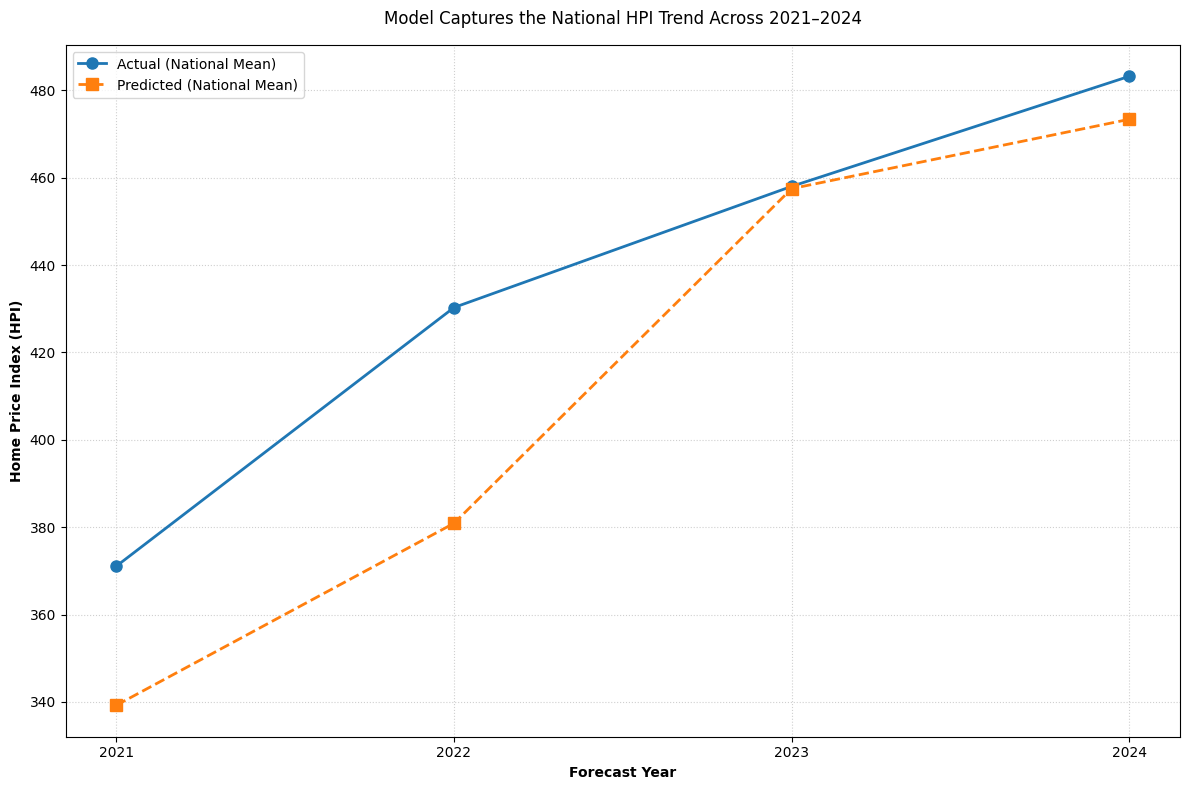

In [60]:
print("Aggregating YoY performance metrics...\n")

# 1. Combining the existing validation and test tables into one master timeline
# Added climate_risk_score to the combination to track hazard intensity over time
cols_to_keep = ["target_year", "actual_hpi", "predicted_hpi"]
if "climate_risk_score" in val_table.columns:
    cols_to_keep.append("climate_risk_score")

eval_all = pd.concat(
    [
        val_table[cols_to_keep],
        test_table[cols_to_keep],
    ],
    ignore_index=True,
)

# Calculating rigorous metrics for each specific year
rows = []
for ty, sub in eval_all.groupby("target_year"):
    # Calculating the mean climate risk for that year to provide environmental context
    avg_climate_risk = (
        sub["climate_risk_score"].mean()
        if "climate_risk_score" in sub.columns
        else np.nan
    )

    rows.append(
        {
            "target_year": int(ty),
            "n": int(len(sub)),
            "Avg_Climate_Risk": round(avg_climate_risk, 2), 
            "RMSE": rmse(sub["actual_hpi"], sub["predicted_hpi"]),
            "MAE": float(mean_absolute_error(sub["actual_hpi"], sub["predicted_hpi"])),
            "R2": float(r2_score(sub["actual_hpi"], sub["predicted_hpi"])),
            "MAPE%": safe_mape(sub["actual_hpi"], sub["predicted_hpi"]),
            "Corr": corr(sub["actual_hpi"], sub["predicted_hpi"]),
        }
    )

# Building the DataFrame and print the raw table 
metrics_by_year = pd.DataFrame(rows).sort_values("target_year").reset_index(drop=True)
print(metrics_by_year.to_string())


# Calculating the national average HPI per year
ts = (
    eval_all.groupby("target_year")[["actual_hpi", "predicted_hpi"]]
    .mean()
    .reset_index()
    .sort_values("target_year")
)

plt.figure(figsize=(12, 8))

# Plotting actual vs predicted with distinct
plt.plot(
    ts["target_year"],
    ts["actual_hpi"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="#1f77b4",
    label="Actual (National Mean)",
)
plt.plot(
    ts["target_year"],
    ts["predicted_hpi"],
    marker="s",
    markersize=8,
    linewidth=2,
    color="#ff7f0e",
    linestyle="--",
    label="Predicted (National Mean)",
)

# Formatting for presentations
plt.xticks(ts["target_year"])  
plt.xlabel("Forecast Year", fontweight="bold")
plt.ylabel("Home Price Index (HPI)", fontweight="bold")
plt.title("Model Captures the National HPI Trend Across 2021–2024", pad=15)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

### STATE-LEVEL AGGREGATION & VISUALIZATION

Generating cleaned regional state-level trendlines with guide lines...


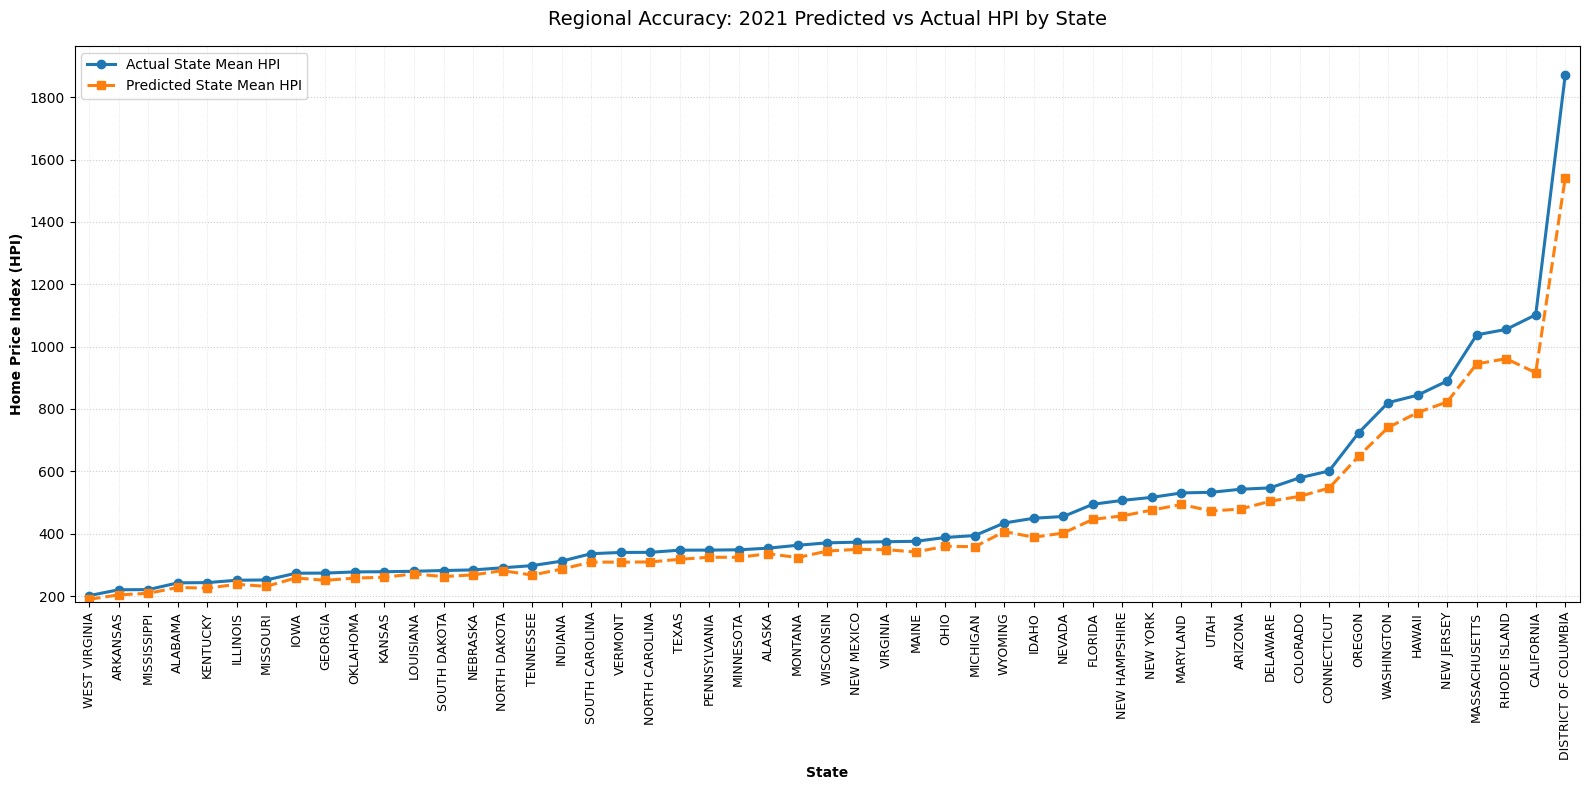

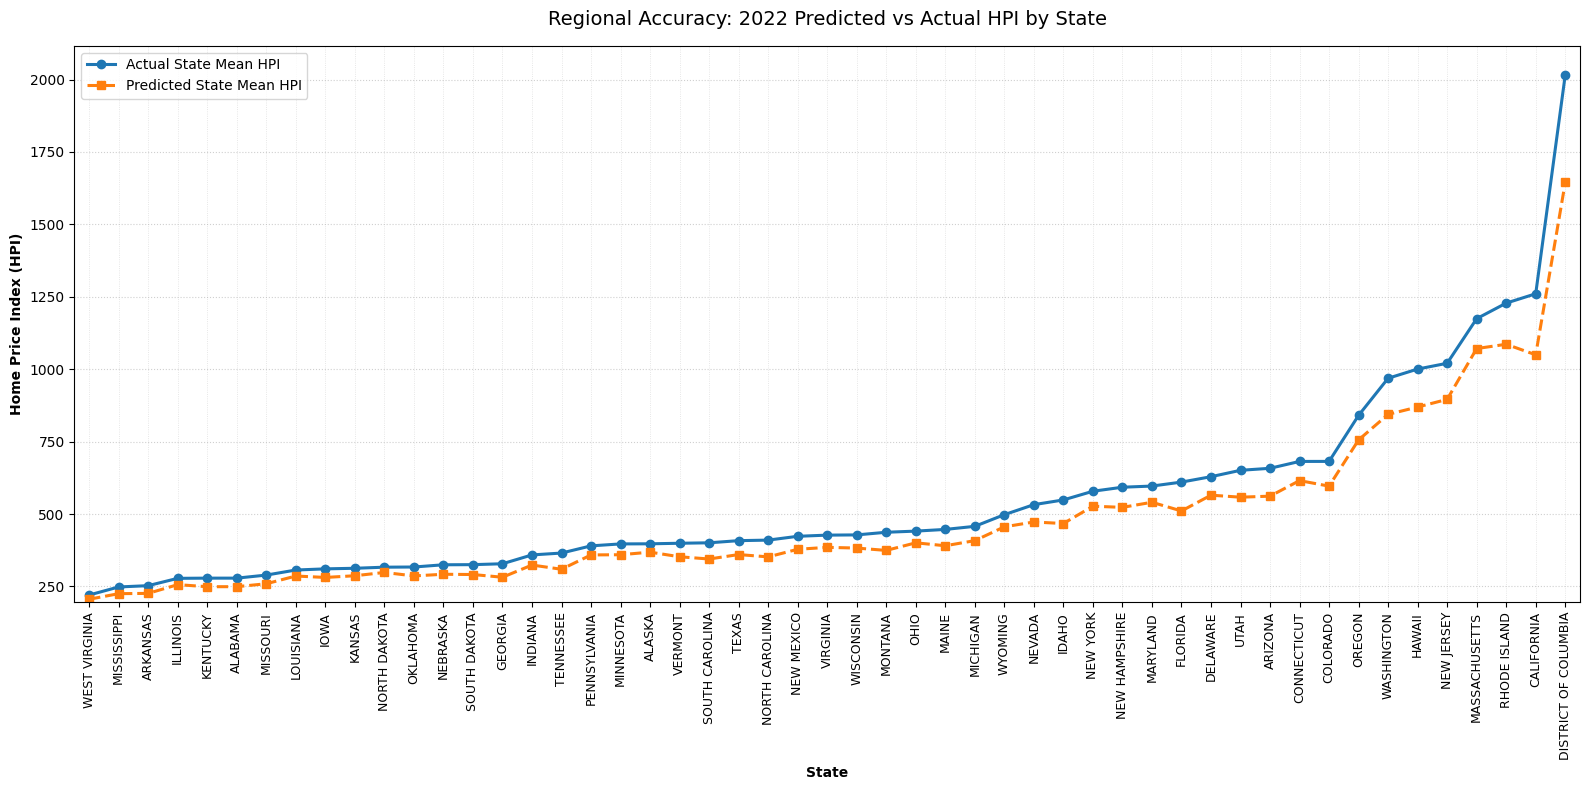

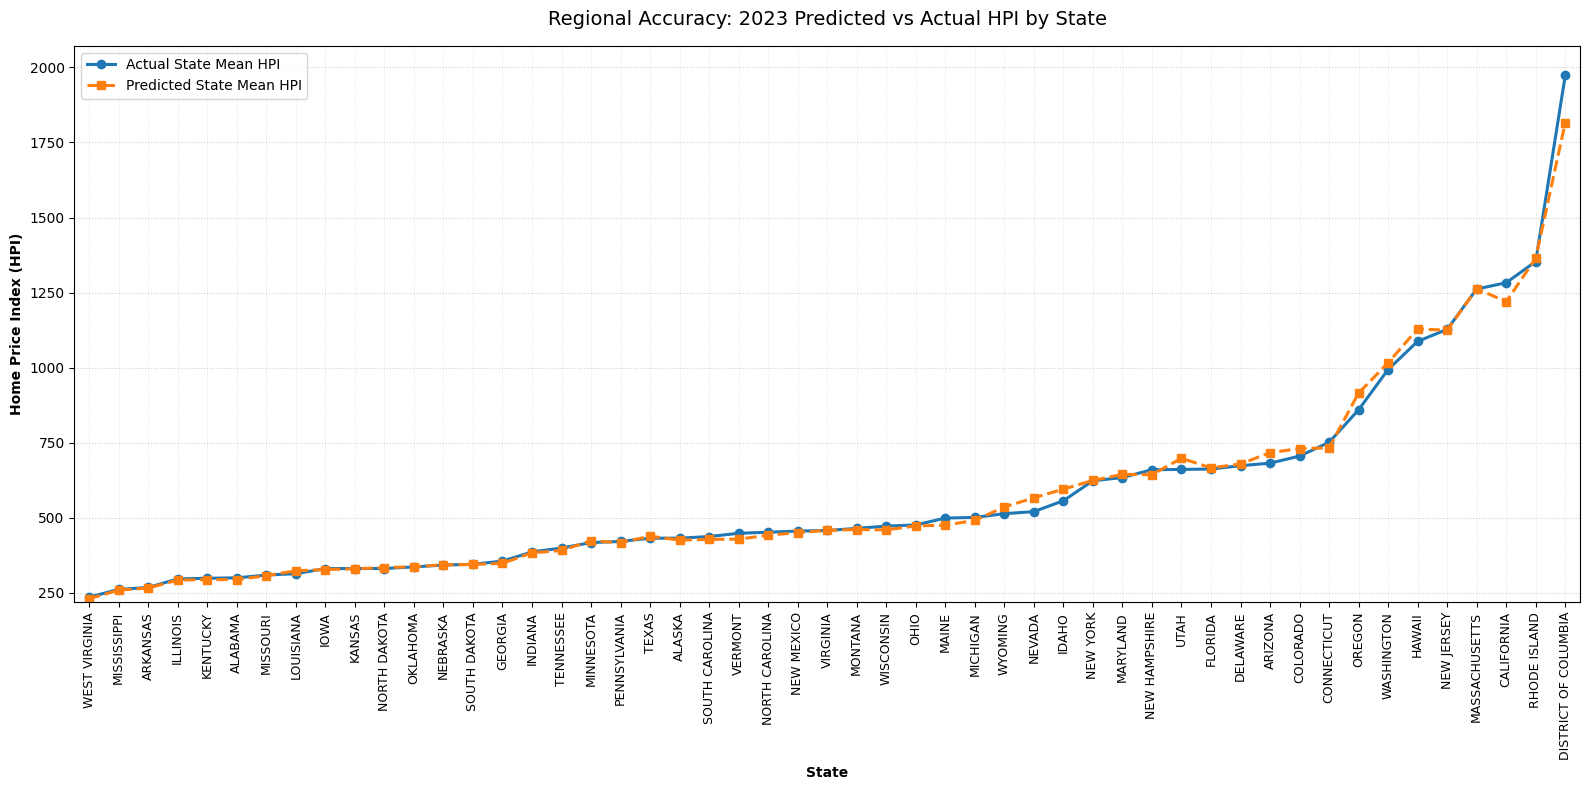

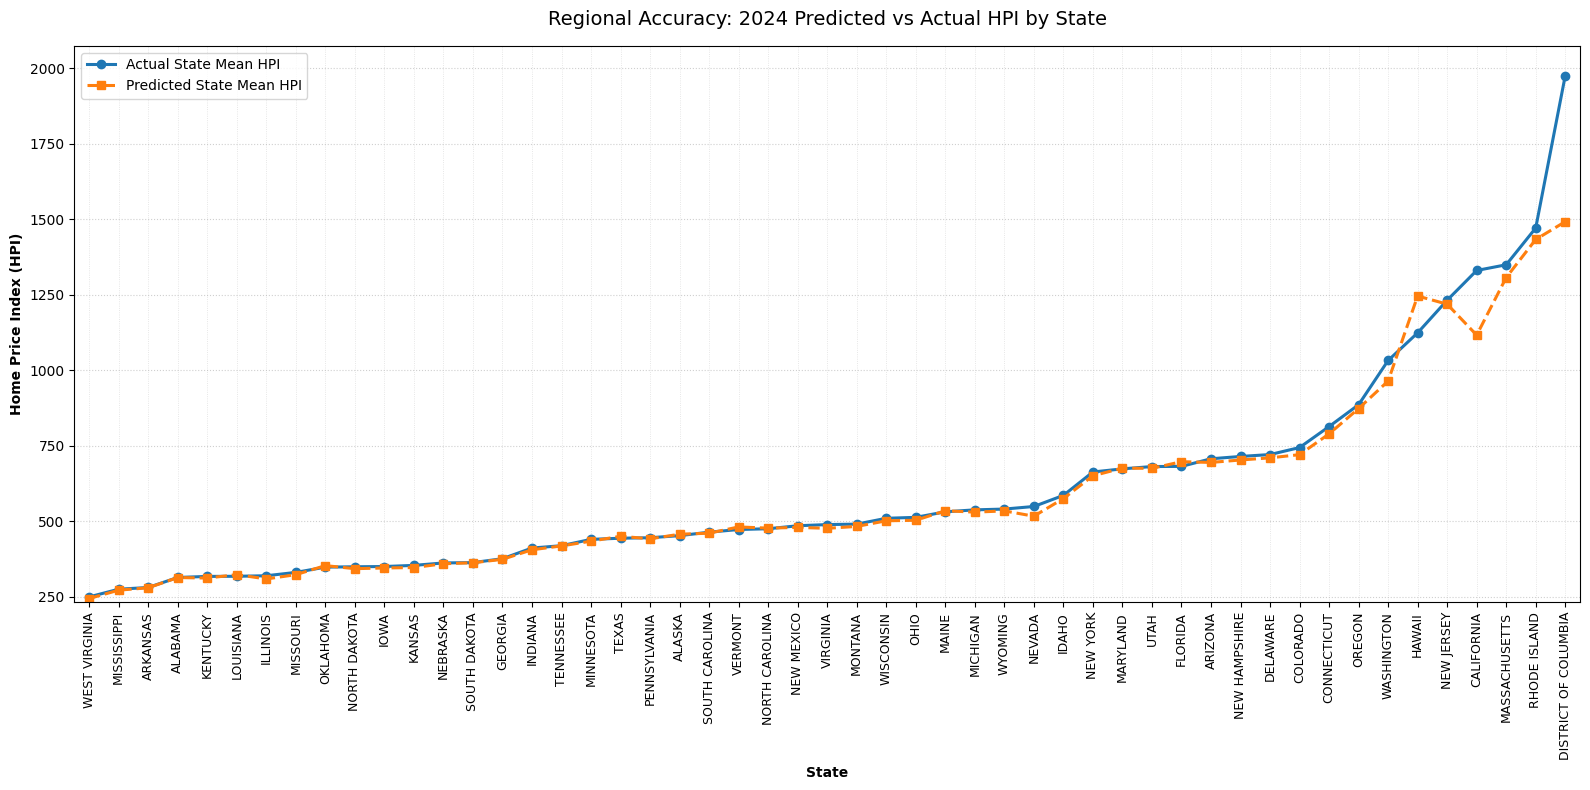

In [61]:
print("Generating cleaned regional state-level trendlines with guide lines...")

import pandas as pd
import matplotlib.pyplot as plt

# Building clean county -> state mapping
county_state = df[["county_fips5", "state"]].copy()
county_state["county_fips5"] = county_state["county_fips5"].astype(str).str.zfill(5)
county_state = county_state.drop_duplicates(subset="county_fips5")

# Building OOS dataframe
oos = pd.concat([val_table, test_table], ignore_index=True)
oos["county_fips5"] = oos["county_fips5"].astype(str).str.zfill(5)
oos = oos.merge(county_state, on="county_fips5", how="left")
oos = oos.dropna(subset=["state"])

# Plotting one chart per year
years = sorted(oos["target_year"].dropna().unique())

for yr in years:
    sub = oos[oos["target_year"] == yr].copy()

    state_year = (
        sub.groupby("state", as_index=False)[["actual_hpi", "predicted_hpi"]]
        .mean()
        .sort_values("actual_hpi")
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(16, 8))

    x = list(range(len(state_year)))
    actual = state_year["actual_hpi"].values
    predicted = state_year["predicted_hpi"].values

    # Plotting the two lines
    ax.plot(x, actual, marker="o", linewidth=2.2, label="Actual State Mean HPI")
    ax.plot(
        x,
        predicted,
        marker="s",
        linestyle="--",
        linewidth=2.2,
        label="Predicted State Mean HPI",
    )

    # Drawing faint vertical guide lines from x-axis upward
    ymin = min(actual.min(), predicted.min())
    ymax = max(actual.max(), predicted.max())
    ax.set_ylim(ymin * 0.95, ymax * 1.05)

    for i in x:
        ax.axvline(i, color="gray", linestyle=":", linewidth=0.6, alpha=0.25, zorder=0)

    # Labels and title
    ax.set_title(
        f"Regional Accuracy: {yr} Predicted vs Actual HPI by State", fontsize=14, pad=15
    )
    ax.set_xlabel("State", fontweight="bold")
    ax.set_ylabel("Home Price Index (HPI)", fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(state_year["state"], rotation=90, ha="center", fontsize=9)

    ax.grid(axis="y", linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", frameon=True)
    ax.margins(x=0.01)

    plt.tight_layout()
    plt.show()

### DISTRIBUTION DIAGNOSTICS: STATE-LEVEL QQ PLOT

Generating State-level QQ Plot...


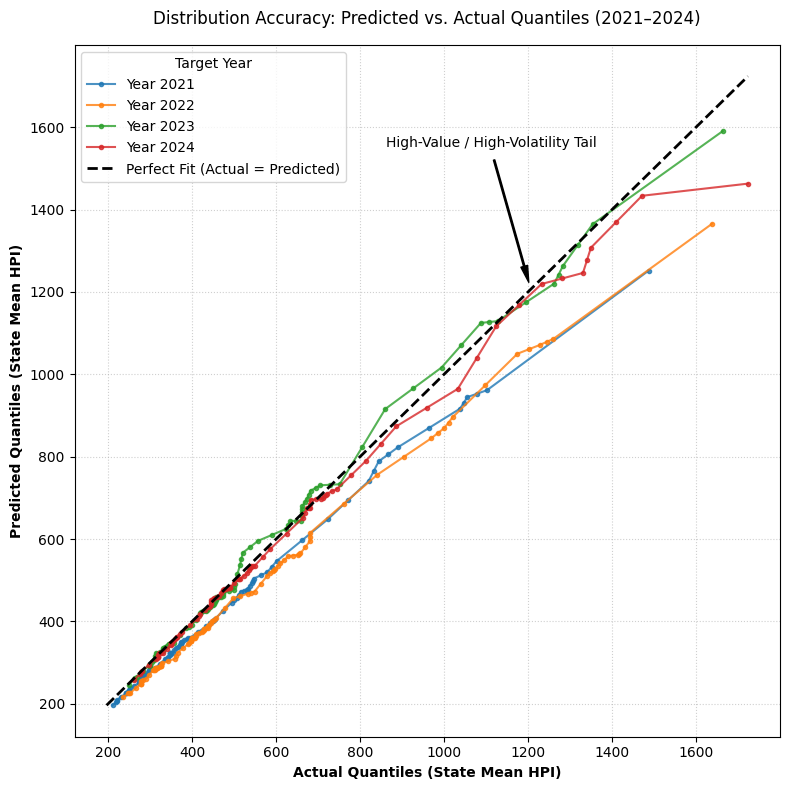

In [62]:
print("Generating State-level QQ Plot...")

# Aggregating to STATE means per year using our existing 'oos' dataframe
# We use the 'oos' dataframe which now contains our climate-enriched data
state_oos = (
    oos.groupby(["target_year", "state"])[["actual_hpi", "predicted_hpi"]]
    .mean()
    .reset_index()
)

# Defining 99 quantiles (1st percentile to 99th percentile)
quantiles = np.linspace(0.01, 0.99, 99)

plt.figure(figsize=(8, 8))

all_min = np.inf
all_max = -np.inf

# Plotting Loop: One quantile curve per year
# Different colors help us see if 2024 (high climate stress) deviates more than 2021.
for yr in sorted(state_oos["target_year"].unique()):
    sub = state_oos[state_oos["target_year"] == yr].dropna(
        subset=["actual_hpi", "predicted_hpi"]
    )

    if sub.empty:
        continue

    # Calculating the quantiles for reality vs predictions
    q_actual = np.quantile(sub["actual_hpi"].values, quantiles)
    q_pred = np.quantile(sub["predicted_hpi"].values, quantiles)

    # Tracking the absolute min and max so we can draw a perfect 45-degree line later
    all_min = min(all_min, q_actual.min(), q_pred.min())
    all_max = max(all_max, q_actual.max(), q_pred.max())

    # Plotting the curve for this specific year
    plt.plot(
        q_actual,
        q_pred,
        marker=".",
        markersize=6,  
        linewidth=1.5,
        alpha=0.8,
        label=f"Year {yr}",
    )

# Drawing the 45-degree reference line
# If the dots fall below this line at high HPI levels, the model is under-predicting the market.
plt.plot(
    [all_min, all_max],
    [all_min, all_max],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Perfect Fit (Actual = Predicted)",
)

# Formatting for presentations
plt.xlabel("Actual Quantiles (State Mean HPI)", fontweight="bold")
plt.ylabel("Predicted Quantiles (State Mean HPI)", fontweight="bold")
plt.title("Distribution Accuracy: Predicted vs. Actual Quantiles (2021–2024)", pad=15)
plt.legend(title="Target Year", loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.annotate(
    "High-Value / High-Volatility Tail",
    xy=(all_max * 0.7, all_max * 0.7),
    xytext=(all_max * 0.5, all_max * 0.9),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
)

plt.tight_layout()
plt.show()

### PRODUCTION REFIT: TRAIN ON ALL DATA (2000–2022)

Training holdout model on historical data (2000-2022)...
Generating 2024 holdout forecasts from 2023 inputs...

------------------------------------------------------------
HONEST HOLDOUT MODEL PERFORMANCE: 2024 OUT-OF-SAMPLE
------------------------------------------------------------
RMSE: 47.7593
MAE : 23.4745
R2  : 0.9802

[+] Top 10 Counties with Highest Error (Cross-reference with climate_risk_score):


,county_fips5,predicted_hpi,climate_risk_score,actual_hpi,error,abs_error,pct_error
196,06085,2323.392578,1442.911574,2983.76,-660.367422,660.367422,-22.132056
193,06079,2026.971680,1562.643981,2629.12,-602.148320,602.148320,-22.903037
195,06083,1952.898438,703.457165,2520.53,-567.631563,567.631563,-22.520326
1665,36047,2003.671997,468.866317,2481.50,-477.828003,477.828003,-19.255612
2628,53033,1979.058838,118.932993,2431.17,-452.111162,452.111162,-18.596444
172,06037,1921.855957,5246.509394,2356.07,-434.214043,434.214043,-18.429590
257,08097,676.661682,63.455268,1101.41,-424.748318,424.748318,-38.564051
2642,53061,1713.553589,205.652626,2130.43,-416.876411,416.876411,-19.567712
225,08031,1682.953857,837.698664,2088.14,-405.186143,405.186143,-19.404166
154,06001,2178.781250,673.502408,2571.78,-392.998750,392.998750,-15.281196


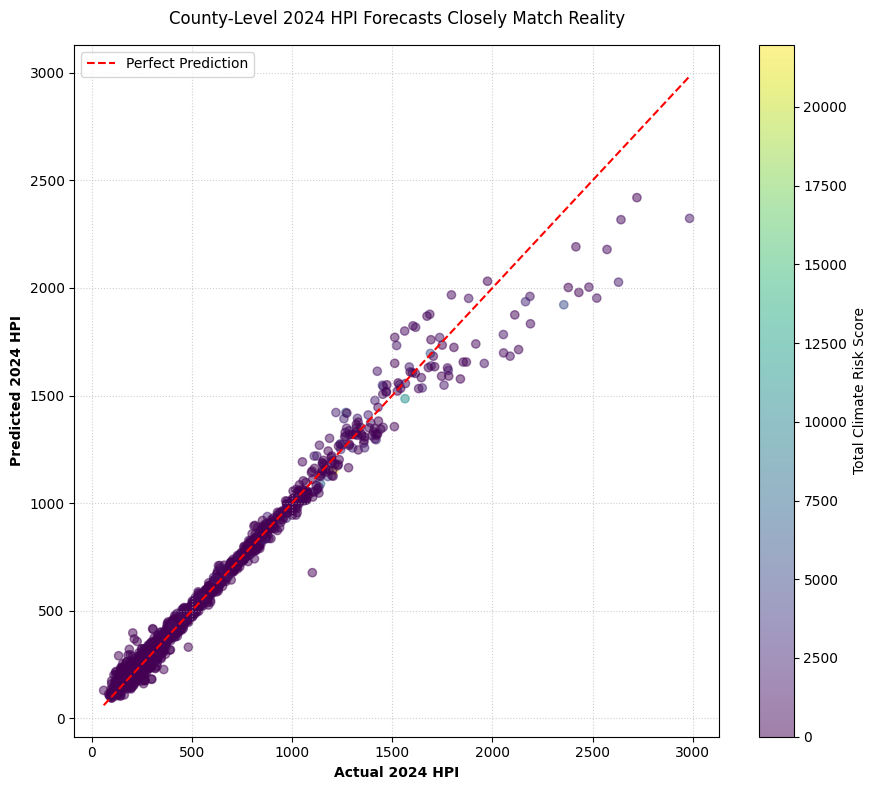

In [63]:
print("Training holdout model on historical data (2000-2022)...")
print("Generating 2024 holdout forecasts from 2023 inputs...")

# Filtering training data to include the most recent available years
final_train = model_df[model_df["yr"].between(2000, 2022)].copy()
X_final = final_train[feature_cols].copy()
y_final = final_train[TARGET].copy()

# Handling missing values and infinite numbers
X_final.replace([np.inf, -np.inf], np.nan, inplace=True)
final_medians = X_final.median(numeric_only=True)
X_final = X_final.fillna(final_medians)

# Log-transforming the target for better model performance on skewed HPI data
y_final_log = np.log1p(y_final)

# Extracting Hyperparameters
# We use the parameters from your validated model.
# Using the optimized parameters we discussed to ensure Climate features are weighted correctly.
try:
    final_params = xgb_model.get_params()
except NameError:
    print("Variable 'xgb_model' not found. Using optimized fallback parameters...")
    final_params = {
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "n_jobs": -1,
        "random_state": 42,
        "importance_type": "total_gain",
    }

# Removing early stopping as we are refitting on the full dataset without a val set
final_params.pop("early_stopping_rounds", None)

final_model = XGBRegressor(**final_params)
final_model.fit(X_final, y_final_log, verbose=False)


# PREDICT 2024 (Using 2023 feature rows as input)

pred_input_2023 = model_df[model_df["yr"] == 2023].copy()
X_2024 = pred_input_2023[feature_cols].copy()

X_2024.replace([np.inf, -np.inf], np.nan, inplace=True)
X_2024 = X_2024.fillna(final_medians)

# Generating predictions and convert back from log-scale
pred_2024 = np.expm1(final_model.predict(X_2024))


# MERGE ACTUALS & EVALUATE

actual_2024 = df[df["yr"] == 2024][["county_fips5", "index_nsa"]].copy()
actual_2024["county_fips5"] = actual_2024["county_fips5"].astype(str).str.zfill(5)
actual_2024 = actual_2024.rename(columns={"index_nsa": "actual_hpi"})

# Creating comparison table
# We add total_climate_risk_score here to investigate if high errors correlate with hazards
eval_2024 = pd.DataFrame(
    {
        "county_fips5": pred_input_2023["county_fips5"].astype(str).str.zfill(5),
        "predicted_hpi": pred_2024,
        "climate_risk_score": (
            pred_input_2023["total_climate_risk_score"].values
            if "total_climate_risk_score" in pred_input_2023.columns
            else np.nan
        ),
    }
)

eval_2024 = eval_2024.merge(actual_2024, on="county_fips5", how="left").dropna(
    subset=["actual_hpi"]
)

# Calculating Error Metrics
eval_2024["error"] = eval_2024["predicted_hpi"] - eval_2024["actual_hpi"]
eval_2024["abs_error"] = eval_2024["error"].abs()
eval_2024["pct_error"] = (eval_2024["error"] / eval_2024["actual_hpi"]) * 100.0

print(f"\n{'-'*60}\nHONEST HOLDOUT MODEL PERFORMANCE: 2024 OUT-OF-SAMPLE\n{'-'*60}")
print(f"RMSE: {rmse(eval_2024['actual_hpi'], eval_2024['predicted_hpi']):.4f}")
print(
    f"MAE : {mean_absolute_error(eval_2024['actual_hpi'], eval_2024['predicted_hpi']):.4f}"
)
print(f"R2  : {r2_score(eval_2024['actual_hpi'], eval_2024['predicted_hpi']):.4f}")

print(
    "\n[+] Top 10 Counties with Highest Error (Cross-reference with climate_risk_score):"
)
display(eval_2024.sort_values("abs_error", ascending=False).head(10))


# SCATTER PLOT WITH CLIMATE COLORING

plt.figure(figsize=(9, 8))

# Coloring points by climate risk to see if hazards drive the 2024 variance
sc = plt.scatter(
    eval_2024["actual_hpi"],
    eval_2024["predicted_hpi"],
    c=eval_2024["climate_risk_score"],
    cmap="viridis",
    alpha=0.5,
)
cbar = plt.colorbar(sc)
cbar.set_label("Total Climate Risk Score")

# Drawing 45-degree reference line
mn = min(eval_2024["actual_hpi"].min(), eval_2024["predicted_hpi"].min())
mx = max(eval_2024["actual_hpi"].max(), eval_2024["predicted_hpi"].max())
plt.plot([mn, mx], [mn, mx], color="red", linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual 2024 HPI", fontweight="bold")
plt.ylabel("Predicted 2024 HPI", fontweight="bold")
plt.title(
    "County-Level 2024 HPI Forecasts Closely Match Reality", pad=15
)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2024 PREDICTED VS ACTUAL HPI BY STATE

Generating state-level 2024 HPI chart...


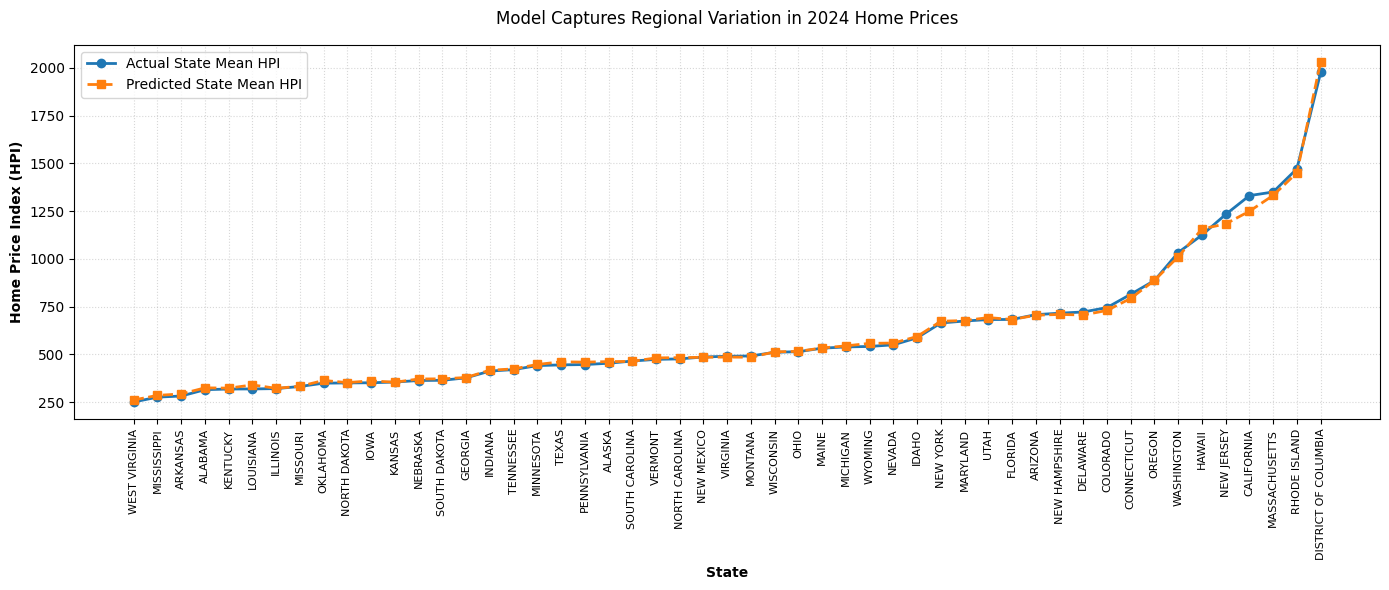

In [64]:
print("Generating state-level 2024 HPI chart...")

# Building county -> state mapping from original dataframe
county_to_state = df[["county_fips5", "state"]].copy()
county_to_state["county_fips5"] = county_to_state["county_fips5"].astype(str).str.zfill(5)
county_to_state = county_to_state.drop_duplicates(subset="county_fips5")

# Merging state names into evaluation table
state_eval_2024 = eval_2024.copy()
state_eval_2024["county_fips5"] = state_eval_2024["county_fips5"].astype(str).str.zfill(5)
state_eval_2024 = state_eval_2024.merge(county_to_state, on="county_fips5", how="left")

# Aggregating county results to state means
state_plot = (
    state_eval_2024.groupby("state", as_index=False)[["actual_hpi", "predicted_hpi"]]
    .mean()
    .sort_values("actual_hpi")
    .reset_index(drop=True)
)

# Creating x positions
x = range(len(state_plot))

plt.figure(figsize=(14, 6))

plt.plot(
    x,
    state_plot["actual_hpi"],
    marker="o",
    linewidth=2,
    label="Actual State Mean HPI",
)

plt.plot(
    x,
    state_plot["predicted_hpi"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Predicted State Mean HPI",
)

plt.xticks(x, state_plot["state"], rotation=90, fontsize=8)
plt.xlabel("State", fontweight="bold")
plt.ylabel("Home Price Index (HPI)", fontweight="bold")
plt.title("Model Captures Regional Variation in 2024 Home Prices", pad=15)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### FEATURE IMPORTANCE: XGBOOST BUILT-IN IMPORTANCE

Generating built-in XGBoost feature importance...

Top 20 Features by XGBoost Importance:


,feature,importance
0,index_nsa,0.856391
1,index_nsa_lag1,0.114792
2,index_nsa_lag2,0.009859
3,index_mom_1y,0.006228
4,yr,0.003520
5,index_mom_2y,0.001691
6,total_amt_purchase,0.001028
7,log_avg_purchase_amt,0.000863
8,pct_total_amt_purchase,0.000666
9,total_home_purchase,0.000551


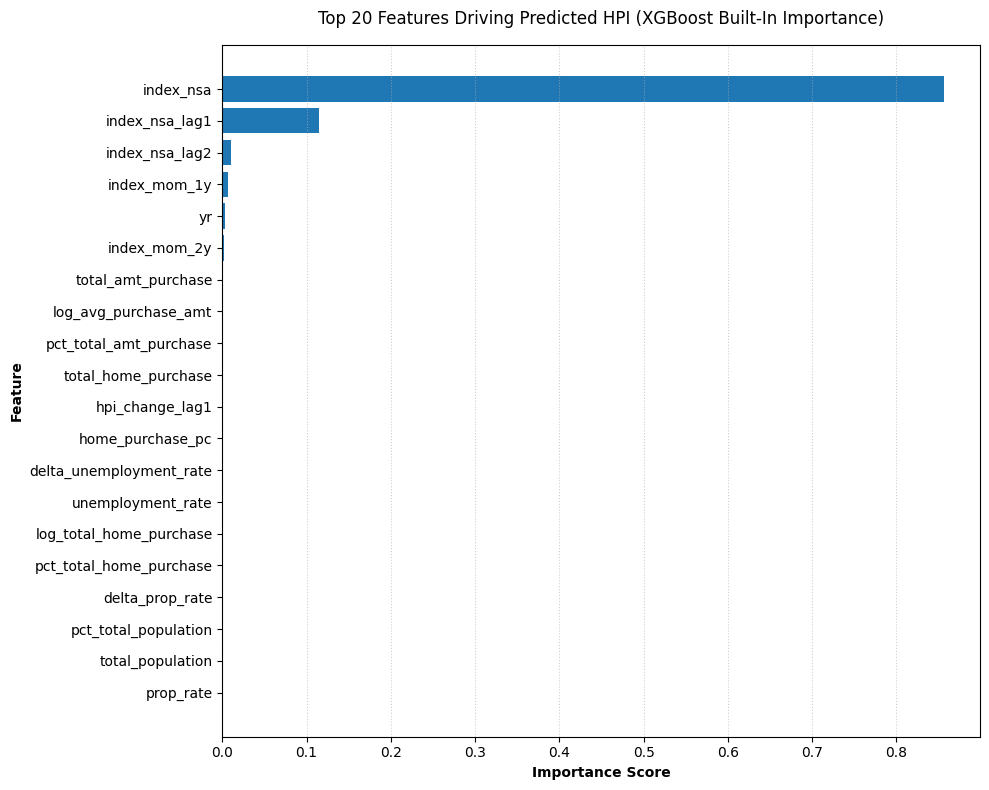

In [65]:
print("Generating built-in XGBoost feature importance...")

import pandas as pd
import matplotlib.pyplot as plt

# Pulling importance scores from the trained model
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": final_model.feature_importances_,
    }
)

# Sorting descending
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(
    drop=True
)

print("\nTop 20 Features by XGBoost Importance:")
display(importance_df.head(20))

top_n = 20
top_imp = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance Score", fontweight="bold")
plt.ylabel("Feature", fontweight="bold")
plt.title(
    f"Top {top_n} Features Driving Predicted HPI (XGBoost Built-In Importance)", pad=15
)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### MULTI-STEP BACKTESTING (2020-2024) -- UPDATED TO MATCH HOLDOUT LOGIC


STARTING RECURSIVE BACKTESTING FOR ERROR DEGRADATION (2020-2024)

Backtest Metrics by Forecast Horizon:


,step_ahead,target_year,n,MAE,RMSE,R2,MAPE_pct
0,1,2020,2766,4.504601,8.045160,0.998870,1.398595
1,2,2021,2766,30.225265,53.846100,0.959546,7.302707
2,3,2022,2766,80.920125,118.643165,0.854054,17.136785
3,4,2023,2766,97.017249,129.929883,0.839479,20.099025
4,5,2024,2766,111.194541,143.205698,0.821889,22.376582



Calculated Historical Error Margins (MAPE):
Step 1 (Target 2020): 1.40%
Step 2 (Target 2021): 7.30%
Step 3 (Target 2022): 17.14%
Step 4 (Target 2023): 20.10%
Step 5 (Target 2024): 22.38%


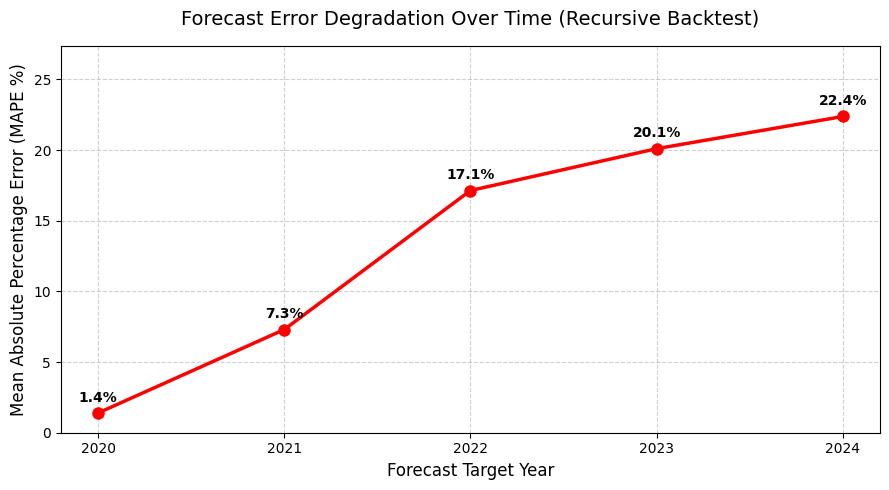

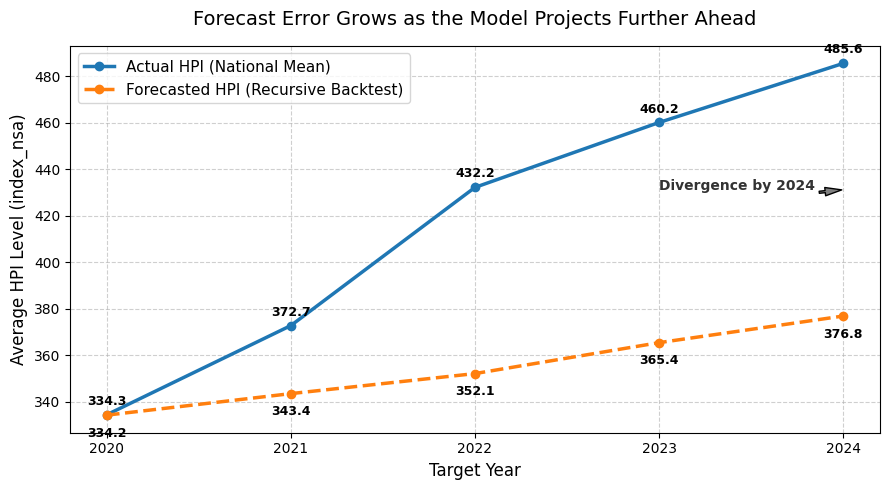

In [66]:
print("\n" + "=" * 60)
print("STARTING RECURSIVE BACKTESTING FOR ERROR DEGRADATION (2020-2024)")
print("=" * 60)

backtest_start_yr = 2019
backtest_horizon = 5  # Predicting target years 2020-2024


# TRAIN BACKTEST MODEL ONLY ON DATA AVAILABLE THROUGH 2019

bt_train = model_df[model_df["yr"] <= backtest_start_yr].copy()

X_bt_train = bt_train[feature_cols].copy()
y_bt_train = bt_train[TARGET].copy()

# Replaceing inf with NaN
X_bt_train.replace([np.inf, -np.inf], np.nan, inplace=True)

# fitting medians only on the backtest training data
bt_medians = X_bt_train.median(numeric_only=True)
X_bt_train = X_bt_train.fillna(bt_medians)

# Log-transforming target
y_bt_train_log = np.log1p(y_bt_train)

# Reusing validated hyperparameters
bt_params = final_params.copy()
bt_params.pop("early_stopping_rounds", None)

bt_model = XGBRegressor(**bt_params)
bt_model.fit(X_bt_train, y_bt_train_log, verbose=False)


# INITIALIZE RECURSIVE LOOP WITH 2019 FEATURE ROWS

current_bt_features = model_df[model_df["yr"] == backtest_start_yr].copy()
current_bt_features[feature_cols] = (
    current_bt_features[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(bt_medians)
)

backtest_results = []

autoregressive_cols = {
    "index_nsa",
    "index_nsa_lag1",
    "index_nsa_lag2",
    "index_mom_1y",
    "index_mom_2y",
    "hpi_change_lag1",
    "hpi_change_roll3_mean",
    "hpi_change_roll5_mean",
}
exogenous_cols = [c for c in feature_cols if c not in autoregressive_cols]


# RECURSIVE FORECAST LOOP

for step in range(1, backtest_horizon + 1):
    target_yr = backtest_start_yr + step

    # Predicting next year from current features
    X_current = current_bt_features[feature_cols].copy()
    X_current = X_current.replace([np.inf, -np.inf], np.nan).fillna(bt_medians)

    pred_hpi = np.expm1(bt_model.predict(X_current))

    # Storing step results
    step_res = pd.DataFrame(
        {
            "county_fips5": current_bt_features["county_fips5"]
            .astype(str)
            .str.zfill(5),
            "feature_year": current_bt_features["yr"].values,
            "target_year": target_yr,
            "pred_hpi": pred_hpi,
            "step_ahead": step,
        }
    )
    backtest_results.append(step_res)


    # Steping features forward into the next feature year

    next_features = current_bt_features.copy()
    next_features["yr"] = target_yr

    # Updating autoregressive HPI fields using predicted values
    next_features["index_nsa_lag2"] = current_bt_features["index_nsa_lag1"]
    next_features["index_nsa_lag1"] = current_bt_features["index_nsa"]
    next_features["index_nsa"] = pred_hpi

    next_features["index_mom_1y"] = (
        next_features["index_nsa"] - next_features["index_nsa_lag1"]
    )
    next_features["index_mom_2y"] = (
        next_features["index_nsa"] - next_features["index_nsa_lag2"]
    )

    # Recomputing lagged HPI growth proxy
    denom = next_features["index_nsa_lag1"].replace(0, np.nan)
    next_features["hpi_change_lag1"] = (
        next_features["index_nsa"] - next_features["index_nsa_lag1"]
    ) / denom

    # Injecting actual exogenous values for that feature year when available
    actual_next_yr_data = model_df[model_df["yr"] == target_yr].copy()
    if not actual_next_yr_data.empty:
        actual_next_yr_data["county_fips5"] = (
            actual_next_yr_data["county_fips5"].astype(str).str.zfill(5)
        )
        next_features["county_fips5"] = (
            next_features["county_fips5"].astype(str).str.zfill(5)
        )

        next_features = next_features.drop(
            columns=[c for c in exogenous_cols if c in next_features.columns],
            errors="ignore",
        ).merge(
            actual_next_yr_data[["county_fips5"] + exogenous_cols],
            on="county_fips5",
            how="left",
        )

    # Final cleanup before next recursive step
    next_features[feature_cols] = (
        next_features[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(bt_medians)
    )

    current_bt_features = next_features.copy()


# EVALUATING BACKTEST AGAINST ACTUALS

bt_df = pd.concat(backtest_results, ignore_index=True)

actuals = df[["county_fips5", "yr", "index_nsa"]].copy()
actuals["county_fips5"] = actuals["county_fips5"].astype(str).str.zfill(5)
actuals = actuals.rename(columns={"yr": "target_year", "index_nsa": "actual_hpi"})

bt_eval = bt_df.merge(actuals, on=["county_fips5", "target_year"], how="left").dropna(
    subset=["actual_hpi"]
)

bt_eval["error"] = bt_eval["pred_hpi"] - bt_eval["actual_hpi"]
bt_eval["abs_error"] = bt_eval["error"].abs()
bt_eval["pct_error"] = (bt_eval["error"] / bt_eval["actual_hpi"]) * 100.0


# YEAR-BY-YEAR BACKTEST METRICS

rows = []
for step in range(1, backtest_horizon + 1):
    step_data = bt_eval[bt_eval["step_ahead"] == step].copy()
    if len(step_data) == 0:
        continue

    rows.append(
        {
            "step_ahead": step,
            "target_year": backtest_start_yr + step,
            "n": len(step_data),
            "MAE": mean_absolute_error(step_data["actual_hpi"], step_data["pred_hpi"]),
            "RMSE": rmse(step_data["actual_hpi"], step_data["pred_hpi"]),
            "R2": r2_score(step_data["actual_hpi"], step_data["pred_hpi"]),
            "MAPE_pct": np.mean(
                np.abs(
                    (step_data["actual_hpi"] - step_data["pred_hpi"])
                    / step_data["actual_hpi"]
                )
            )
            * 100.0,
        }
    )

backtest_metrics = pd.DataFrame(rows)

print("\nBacktest Metrics by Forecast Horizon:")
display(backtest_metrics)

print("\nCalculated Historical Error Margins (MAPE):")
for _, row in backtest_metrics.iterrows():
    print(
        f"Step {int(row['step_ahead'])} "
        f"(Target {int(row['target_year'])}): "
        f"{row['MAPE_pct']:.2f}%"
    )


# BACKTEST ERROR DEGRADATION CHART

plt.figure(figsize=(9, 5))
plt.plot(
    backtest_metrics["target_year"],
    backtest_metrics["MAPE_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="red",
)

plt.title(
    "Forecast Error Degradation Over Time (Recursive Backtest)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Forecast Target Year", fontsize=12)
plt.ylabel("Mean Absolute Percentage Error (MAPE %)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(backtest_metrics["target_year"])

for x, y in zip(backtest_metrics["target_year"], backtest_metrics["MAPE_pct"]):
    plt.text(x, y + 0.8, f"{y:.1f}%", ha="center", fontweight="bold")

plt.ylim(0, backtest_metrics["MAPE_pct"].max() + 5)
plt.tight_layout()
plt.show()


# BACKTEST TRAJECTORY CHART: ACTUAL VS PREDICTED NATIONAL MEAN

bt_mean_trend = (
    bt_eval.groupby("target_year")[["actual_hpi", "pred_hpi"]]
    .mean()
    .reset_index()
    .sort_values("target_year")
)

plt.figure(figsize=(9, 5))

plt.plot(
    bt_mean_trend["target_year"],
    bt_mean_trend["actual_hpi"],
    marker="o",
    linewidth=2.5,
    label="Actual HPI (National Mean)",
)

plt.plot(
    bt_mean_trend["target_year"],
    bt_mean_trend["pred_hpi"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Forecasted HPI (Recursive Backtest)",
)

# Adding numeric labels to dots
for x, y in zip(bt_mean_trend["target_year"], bt_mean_trend["actual_hpi"]):
    plt.text(
        x, y + 3, f"{y:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

for x, y in zip(bt_mean_trend["target_year"], bt_mean_trend["pred_hpi"]):
    plt.text(x, y - 5, f"{y:.1f}", ha="center", va="top", fontsize=9, fontweight="bold")

plt.title(
    "Forecast Error Grows as the Model Projects Further Ahead",
    fontsize=14,
    pad=15,
)
plt.xlabel("Target Year", fontsize=12)
plt.ylabel("Average HPI Level (index_nsa)", fontsize=12)
plt.xticks(bt_mean_trend["target_year"])
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

final_year = bt_mean_trend.iloc[-1]
plt.annotate(
    "Divergence by 2024",
    xy=(
        final_year["target_year"],
        (final_year["actual_hpi"] + final_year["pred_hpi"]) / 2,
    ),
    xytext=(
        final_year["target_year"] - 1.0,
        (final_year["actual_hpi"] + final_year["pred_hpi"]) / 2,
    ),
    arrowprops=dict(facecolor="gray", shrink=0.05, width=1.5, headwidth=6),
    fontsize=10,
    fontweight="bold",
    color="#333333",
)

plt.tight_layout()
plt.show()

### AUTOREGRESSIVE FORECASTING (2025-2030) WITH RISK BOUNDS

In [68]:
print("\n" + "=" * 60)
print("STARTING AUTOREGRESSIVE FORECASTING (2025-2030)")
print("=" * 60)


# BUILDING RISK-MARGIN LOOKUP FROM UPDATED BACKTEST METRICS
risk_curve = {
    int(row["step_ahead"]): float(row["MAPE_pct"]) / 100.0
    for _, row in backtest_metrics.iterrows()
}

print("\nUsing recursive backtest risk margins:")
for step, mape in risk_curve.items():
    print(f"Step {step}: +/- {mape*100:.1f}%")


# STARTING FROM ACTUAL 2024 FEATURE ROWS
current_fcst_features = model_df[model_df["yr"] == 2024].copy()

if current_fcst_features.empty:
    current_fcst_features = df[df["yr"] == 2024].copy()

current_fcst_features["county_fips5"] = (
    current_fcst_features["county_fips5"].astype(str).str.zfill(5)
)

for c in feature_cols:
    if c not in current_fcst_features.columns:
        current_fcst_features[c] = np.nan

# Cleaning feature matrix using training medians from the honest 2000-2022 fit
current_fcst_features[feature_cols] = (
    current_fcst_features[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_medians)
)

future_forecasts = []


# DEFINING HPI-RELATED AUTOREGRESSIVE COLUMNS

autoregressive_cols = {
    "index_nsa",
    "index_nsa_lag1",
    "index_nsa_lag2",
    "index_mom_1y",
    "index_mom_2y",
    "hpi_change_lag1",
    "hpi_change_roll3_mean",
    "hpi_change_roll5_mean",
}

# RECURSIVE FORECAST LOOP: 2025-2030

for target_yr in range(2025, 2031):
    step_ahead = target_yr - 2024

    # Predicting target year from current feature row
    X_current = current_fcst_features[feature_cols].copy()
    X_current = X_current.replace([np.inf, -np.inf], np.nan).fillna(final_medians)

    pred_hpi = np.expm1(final_model.predict(X_current))

    # Risk bound from historical recursive backtest
    max_known_step = max(risk_curve.keys()) if len(risk_curve) > 0 else 5
    risk_step = step_ahead if step_ahead in risk_curve else max_known_step
    current_mape = risk_curve.get(risk_step, 0.25)

    # Storing forecast output
    step_res = pd.DataFrame(
        {
            "county_fips5": current_fcst_features["county_fips5"]
            .astype(str)
            .str.zfill(5),
            "feature_year": current_fcst_features["yr"].values,
            "target_year": target_yr,
            "forecast_hpi": pred_hpi,
            "lower_bound_hpi": pred_hpi * (1 - current_mape),
            "upper_bound_hpi": pred_hpi * (1 + current_mape),
            "risk_margin_pct": current_mape * 100,
            "step_ahead": step_ahead,
        }
    )
    future_forecasts.append(step_res)

    print(f"Forecasted {target_yr}. Applied +/- {current_mape*100:.1f}% risk bound.")

    # Building next year's feature row recursively
    # For 2026+, this uses predicted HPI path.
    # Non-HPI features are carried forward from the latest available row.
  
    next_features = current_fcst_features.copy()
    next_features["yr"] = target_yr

    # Updating HPI-related fields recursively
    if (
        "index_nsa_lag2" in next_features.columns
        and "index_nsa_lag1" in current_fcst_features.columns
    ):
        next_features["index_nsa_lag2"] = current_fcst_features["index_nsa_lag1"]

    if (
        "index_nsa_lag1" in next_features.columns
        and "index_nsa" in current_fcst_features.columns
    ):
        next_features["index_nsa_lag1"] = current_fcst_features["index_nsa"]

    if "index_nsa" in next_features.columns:
        next_features["index_nsa"] = pred_hpi

    if {"index_nsa", "index_nsa_lag1"}.issubset(next_features.columns):
        next_features["index_mom_1y"] = (
            next_features["index_nsa"] - next_features["index_nsa_lag1"]
        )

    if {"index_nsa", "index_nsa_lag2"}.issubset(next_features.columns):
        next_features["index_mom_2y"] = (
            next_features["index_nsa"] - next_features["index_nsa_lag2"]
        )

    if {"index_nsa", "index_nsa_lag1"}.issubset(next_features.columns):
        denom = next_features["index_nsa_lag1"].replace(0, np.nan)
        next_features["hpi_change_lag1"] = (
            next_features["index_nsa"] - next_features["index_nsa_lag1"]
        ) / denom

    # keeping rolling HPI trend features carried forward unless I want
    # to explicitly update them with a custom recursive rule
    for col in ["hpi_change_roll3_mean", "hpi_change_roll5_mean"]:
        if col in current_fcst_features.columns:
            next_features[col] = current_fcst_features[col]

    # Final cleanup
    for c in feature_cols:
        if c not in next_features.columns:
            next_features[c] = np.nan

    next_features[feature_cols] = (
        next_features[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(final_medians)
    )

    current_fcst_features = next_features.copy()

final_map_dataset = pd.concat(future_forecasts, ignore_index=True)

print("\nPipeline complete. Preview of 2025-2030 forecasts with risk bounds:")
display(final_map_dataset.sample(10))

# Saving the forecast data
# final_map_dataset.to_csv("Forecast_2025_2030_Bounds.csv", index=False)
# print("\nSaved: Forecast_2025_2030_Bounds.csv")


STARTING AUTOREGRESSIVE FORECASTING (2025-2030)

Using recursive backtest risk margins:
Step 1: +/- 1.4%
Step 2: +/- 7.3%
Step 3: +/- 17.1%
Step 4: +/- 20.1%
Step 5: +/- 22.4%
Forecasted 2025. Applied +/- 1.4% risk bound.
Forecasted 2026. Applied +/- 7.3% risk bound.
Forecasted 2027. Applied +/- 17.1% risk bound.
Forecasted 2028. Applied +/- 20.1% risk bound.
Forecasted 2029. Applied +/- 22.4% risk bound.
Forecasted 2030. Applied +/- 22.4% risk bound.

Pipeline complete. Preview of 2025-2030 forecasts with risk bounds:


,county_fips5,feature_year,target_year,forecast_hpi,lower_bound_hpi,upper_bound_hpi,risk_margin_pct,step_ahead
3068,10005,2025,2026,759.786438,704.301453,815.271362,7.302707,2
15070,26045,2029,2030,755.515259,586.456787,924.573792,22.376582,6
12050,21023,2028,2029,272.537781,211.553146,333.522430,22.376582,5
13463,48159,2028,2029,450.712189,349.858215,551.566162,22.376582,5
15499,32001,2029,2030,787.176147,611.033081,963.319275,22.376582,6
15537,34027,2029,2030,1578.437866,1225.237427,1931.638306,22.376582,6
6491,21053,2026,2027,112.229027,92.996582,131.461472,17.136785,3
4261,30039,2025,2026,435.445648,403.646332,467.244934,7.302707,2
14400,13279,2029,2030,475.138397,368.818665,581.458130,22.376582,6
14853,21061,2029,2030,370.157318,287.328766,452.985870,22.376582,6


### THE 2025-2030 FORECASTS

Generating forecast visualizations (2025-2030)...


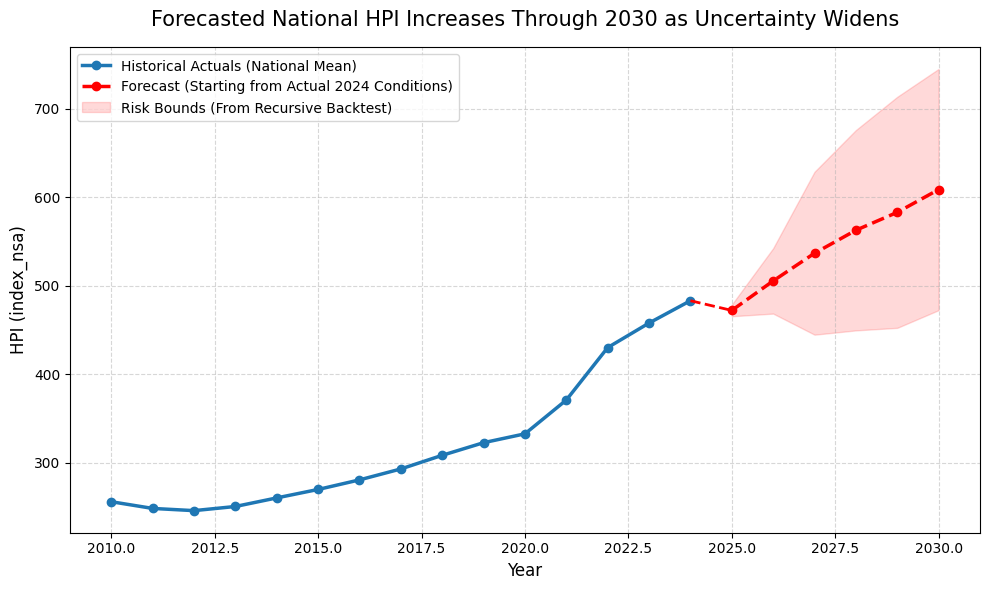

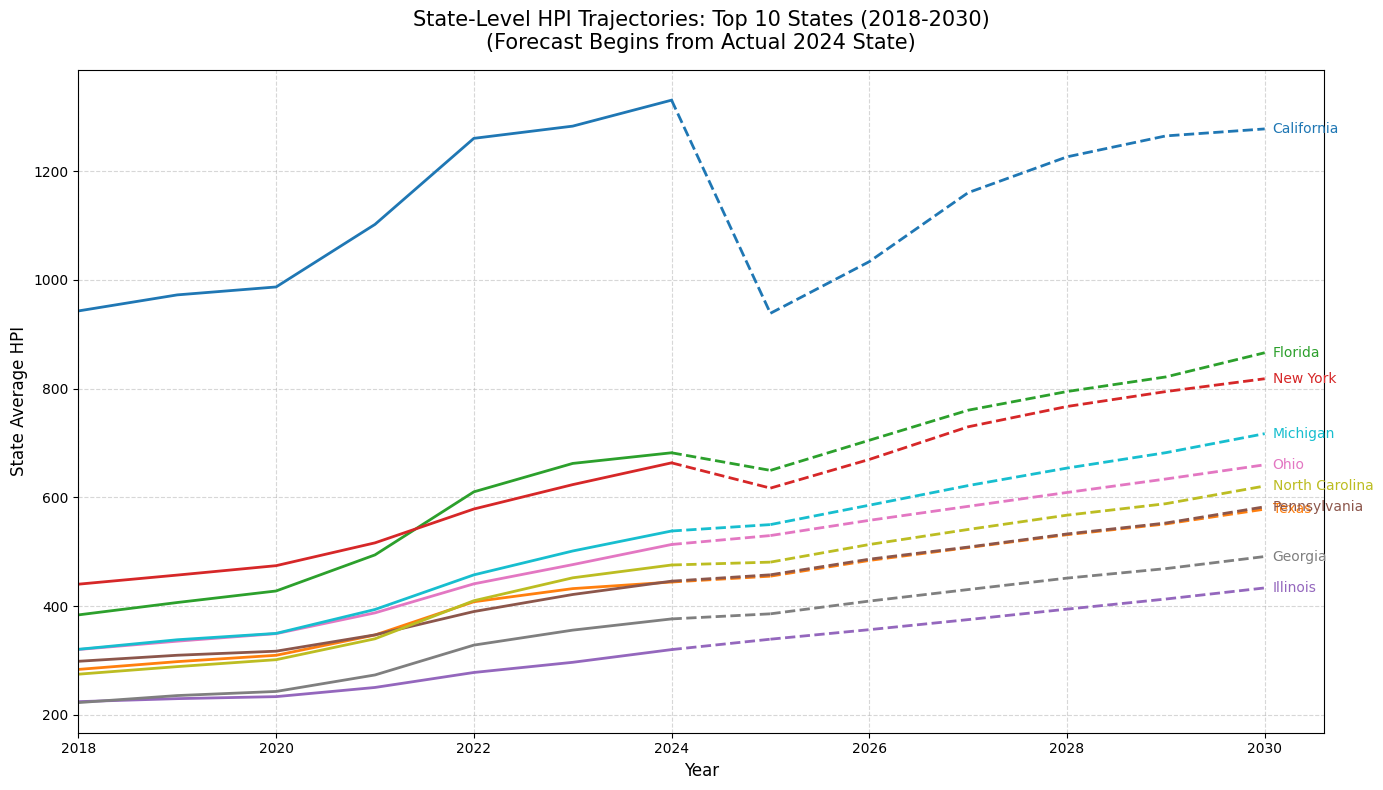

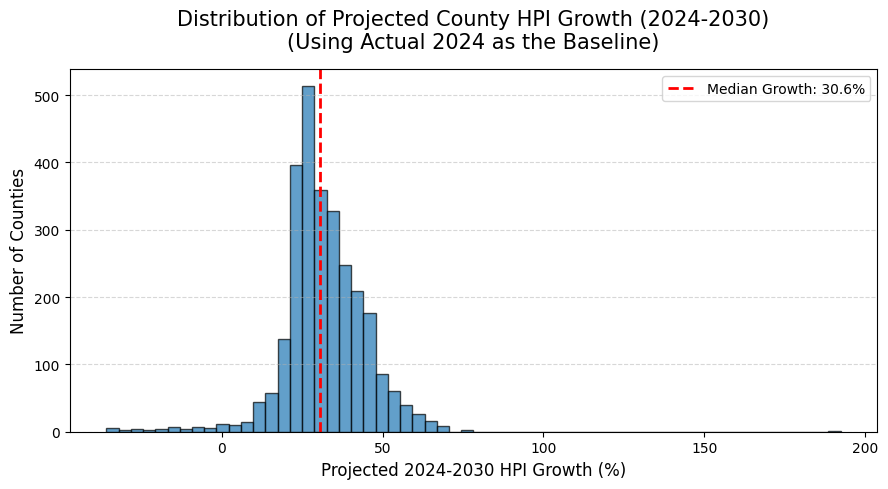

In [69]:
print("Generating forecast visualizations (2025-2030)...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# CLEAN COUNTY -> STATE MAPPING

county_to_state = df[["county_fips5", "state"]].copy()
county_to_state["county_fips5"] = (
    county_to_state["county_fips5"].astype(str).str.zfill(5)
)
county_to_state = county_to_state.drop_duplicates(subset="county_fips5")

final_map_dataset = final_map_dataset.copy()
final_map_dataset["county_fips5"] = (
    final_map_dataset["county_fips5"].astype(str).str.zfill(5)
)

mapped_forecasts = final_map_dataset.merge(
    county_to_state, on="county_fips5", how="left"
)

# CHART (National Mean Forecast with Risk Bounds)

hist_mean = (
    df[df["yr"].between(2010, 2024)]
    .groupby("yr", as_index=False)["index_nsa"]
    .mean()
    .sort_values("yr")
)

fcst_mean = (
    mapped_forecasts.groupby("target_year", as_index=False)[
        ["forecast_hpi", "lower_bound_hpi", "upper_bound_hpi"]
    ]
    .mean()
    .sort_values("target_year")
)

plt.figure(figsize=(10, 6))

# Historical actuals through 2024
plt.plot(
    hist_mean["yr"],
    hist_mean["index_nsa"],
    linewidth=2.5,
    marker="o",
    label="Historical Actuals (National Mean)",
)

# Forecast path from 2025 onward
plt.plot(
    fcst_mean["target_year"],
    fcst_mean["forecast_hpi"],
    linewidth=2.5,
    linestyle="--",
    marker="o",
    color="red",
    label="Forecast (Starting from Actual 2024 Conditions)",
)

# Uncertainty fan
plt.fill_between(
    fcst_mean["target_year"],
    fcst_mean["lower_bound_hpi"],
    fcst_mean["upper_bound_hpi"],
    color="red",
    alpha=0.15,
    label="Risk Bounds (From Recursive Backtest)",
)

# Connect actual 2024 to forecasted 2025
if not hist_mean.empty and not fcst_mean.empty:
    plt.plot(
        [hist_mean.iloc[-1]["yr"], fcst_mean.iloc[0]["target_year"]],
        [hist_mean.iloc[-1]["index_nsa"], fcst_mean.iloc[0]["forecast_hpi"]],
        linestyle="--",
        linewidth=2.0,
        color="red",
    )

plt.title(
    "Forecasted National HPI Increases Through 2030 as Uncertainty Widens",
    fontsize=15,
    pad=15,
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("HPI (index_nsa)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# CHART 2: STATE-LEVEL TRAJECTORIES (Top 10 States) WITH END LABELS

target_states = [
    "CALIFORNIA",
    "TEXAS",
    "FLORIDA",
    "NEW YORK",
    "ILLINOIS",
    "PENNSYLVANIA",
    "OHIO",
    "GEORGIA",
    "NORTH CAROLINA",
    "MICHIGAN",
]

hist_state = df[
    (df["state"].isin(target_states)) & (df["yr"].between(2018, 2024))
].copy()

hist_state_mean = (
    hist_state.groupby(["yr", "state"], as_index=False)["index_nsa"]
    .mean()
    .sort_values(["state", "yr"])
)

fcst_state_mean = mapped_forecasts[mapped_forecasts["state"].isin(target_states)].copy()
fcst_state_mean = (
    fcst_state_mean.groupby(["target_year", "state"], as_index=False)["forecast_hpi"]
    .mean()
    .sort_values(["state", "target_year"])
)

plt.figure(figsize=(14, 8))

colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

for i, state in enumerate(target_states):
    c_hist = hist_state_mean[hist_state_mean["state"] == state]
    c_fcst = fcst_state_mean[fcst_state_mean["state"] == state]

    if c_hist.empty or c_fcst.empty:
        continue

    # Historical actual line through 2024
    plt.plot(
        c_hist["yr"],
        c_hist["index_nsa"],
        color=colors[i],
        linewidth=2,
    )

    # Forecast line from 2025 onward
    plt.plot(
        c_fcst["target_year"],
        c_fcst["forecast_hpi"],
        color=colors[i],
        linewidth=2,
        linestyle="--",
    )

    # Connect actual 2024 to forecast 2025
    plt.plot(
        [c_hist.iloc[-1]["yr"], c_fcst.iloc[0]["target_year"]],
        [c_hist.iloc[-1]["index_nsa"], c_fcst.iloc[0]["forecast_hpi"]],
        color=colors[i],
        linewidth=2,
        linestyle="--",
    )

    # Label state at end of forecast line
    end_x = c_fcst.iloc[-1]["target_year"]
    end_y = c_fcst.iloc[-1]["forecast_hpi"]

    plt.text(
        end_x + 0.08,
        end_y,
        state.title(),
        color=colors[i],
        fontsize=10,
        va="center",
    )

plt.title(
    "State-Level HPI Trajectories: Top 10 States (2018-2030)\n(Forecast Begins from Actual 2024 State)",
    fontsize=15,
    pad=15,
)
plt.xlabel("Year", fontsize=12)
plt.ylabel("State Average HPI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2018, 2030.6)
plt.tight_layout()
plt.show()


# CHART 3: COUNTY-LEVEL GROWTH DISTRIBUTION (2024 TO 2030)

hpi_2030 = mapped_forecasts[mapped_forecasts["target_year"] == 2030][
    ["county_fips5", "forecast_hpi"]
].copy()

hpi_2024 = df[df["yr"] == 2024][["county_fips5", "index_nsa"]].copy()
hpi_2024["county_fips5"] = hpi_2024["county_fips5"].astype(str).str.zfill(5)

growth_df = hpi_2030.merge(hpi_2024, on="county_fips5", how="inner")

growth_df["growth_2024_to_2030_pct"] = (
    (growth_df["forecast_hpi"] - growth_df["index_nsa"]) / growth_df["index_nsa"]
) * 100

plt.figure(figsize=(9, 5))
plt.hist(
    growth_df["growth_2024_to_2030_pct"],
    bins=60,
    edgecolor="black",
    alpha=0.7,
)

median_growth = growth_df["growth_2024_to_2030_pct"].median()

plt.axvline(
    median_growth,
    color="red",
    linestyle="dashed",
    linewidth=2,
    label=f"Median Growth: {median_growth:.1f}%",
)

plt.title(
    "Distribution of Projected County HPI Growth (2024-2030)\n(Using Actual 2024 as the Baseline)",
    fontsize=15,
    pad=15,
)
plt.xlabel("Projected 2024-2030 HPI Growth (%)", fontsize=12)
plt.ylabel("Number of Counties", fontsize=12)
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()